In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import pathlib as Path
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import os
import base64
from io import BytesIO

In [ ]:
file = r'template_date_supply.xlsx'
sheet = 'FACT_ORDER_DAILY'

In [ ]:
df = pd.read_excel(file, sheet_name=sheet)

In [ ]:
#Definindo as cores

COLORS = {
    "Total de Entrada": "#4A4D4A",
    "Confirmado": "#6F856A",              
    "Parcialmente Confirmado": "#B5A35A", 
    "Rejeitado": "#8B3A3A",               
    "Negativo": "#B65F2A",              
    "Texto": "#332B24"
}

In [ ]:
df["Rejection Reason"] = (
    df["Rejection Reason"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["Rejection Reason"] = np.where(

    df["Rejection Reason"].isin(
        ["", "-", "–", "—"]
    ),

    "Not Rejected",

    df["Rejection Reason"]
)

In [ ]:
# Cálculo do valor de faturamento

def calcular_faturamento(row):

    rejection = row["Rejection Reason"]
    net_value = row["Net Value (R$)"]
    order_qty = row["Order Qty"]
    confirmed_qty = row["Confirmed Qty"]

    # Pedido sem rejeição

    if rejection == "Not Rejected":

        return net_value

    # Pedido parcialmente confirmado

    elif row["Order Status"] == "Partially Confirmed":

        if order_qty == 0:

            return 0

        confirmed_value = (
            net_value
            * confirmed_qty
            / order_qty
        )

        return confirmed_value


    # Pedido totalmente rejeitado

    else:

        return 0


df["Faturamento"] = df.apply(
    calcular_faturamento,
    axis=1
)

In [ ]:
df["Causa"] = df["Rejection Reason"]

In [ ]:
causas = (
    df.groupby("Causa", as_index=False)
      ["Faturamento"]
      .sum()
)

In [ ]:
total_entrada = df["Net Value (R$)"].sum()

rejeicoes = (
    df.loc[
        df["Rejection Reason"] != "Not Rejected",
        "Faturamento"
    ].sum()
)

faturamento_potencial = df["Faturamento"].sum()

In [ ]:
conversao = (
    faturamento_potencial / total_entrada
    if total_entrada != 0
    else 0
)

valor_rejeitado = (
    total_entrada - faturamento_potencial
)

In [ ]:
# Checagem dos valores calculados
print(f"Entrada de pedidos: R$ {total_entrada:,.2f}")
print(f"Faturamento potencial: R$ {faturamento_potencial:,.2f}")
print(f"Valor rejeitado: R$ {valor_rejeitado:,.2f}")
print(f"Conversão: {conversao:.1%}")

Entrada de pedidos: R$ 578,618.00
Faturamento potencial: R$ 466,442.00
Valor rejeitado: R$ 112,176.00
Conversão: 80.6%


In [ ]:
import base64
from io import BytesIO

def figura_para_base64(fig):

    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white"
    )

    buffer.seek(0)

    imagem = base64.b64encode(
        buffer.read()
    ).decode("utf-8")

    plt.close(fig)

    return imagem


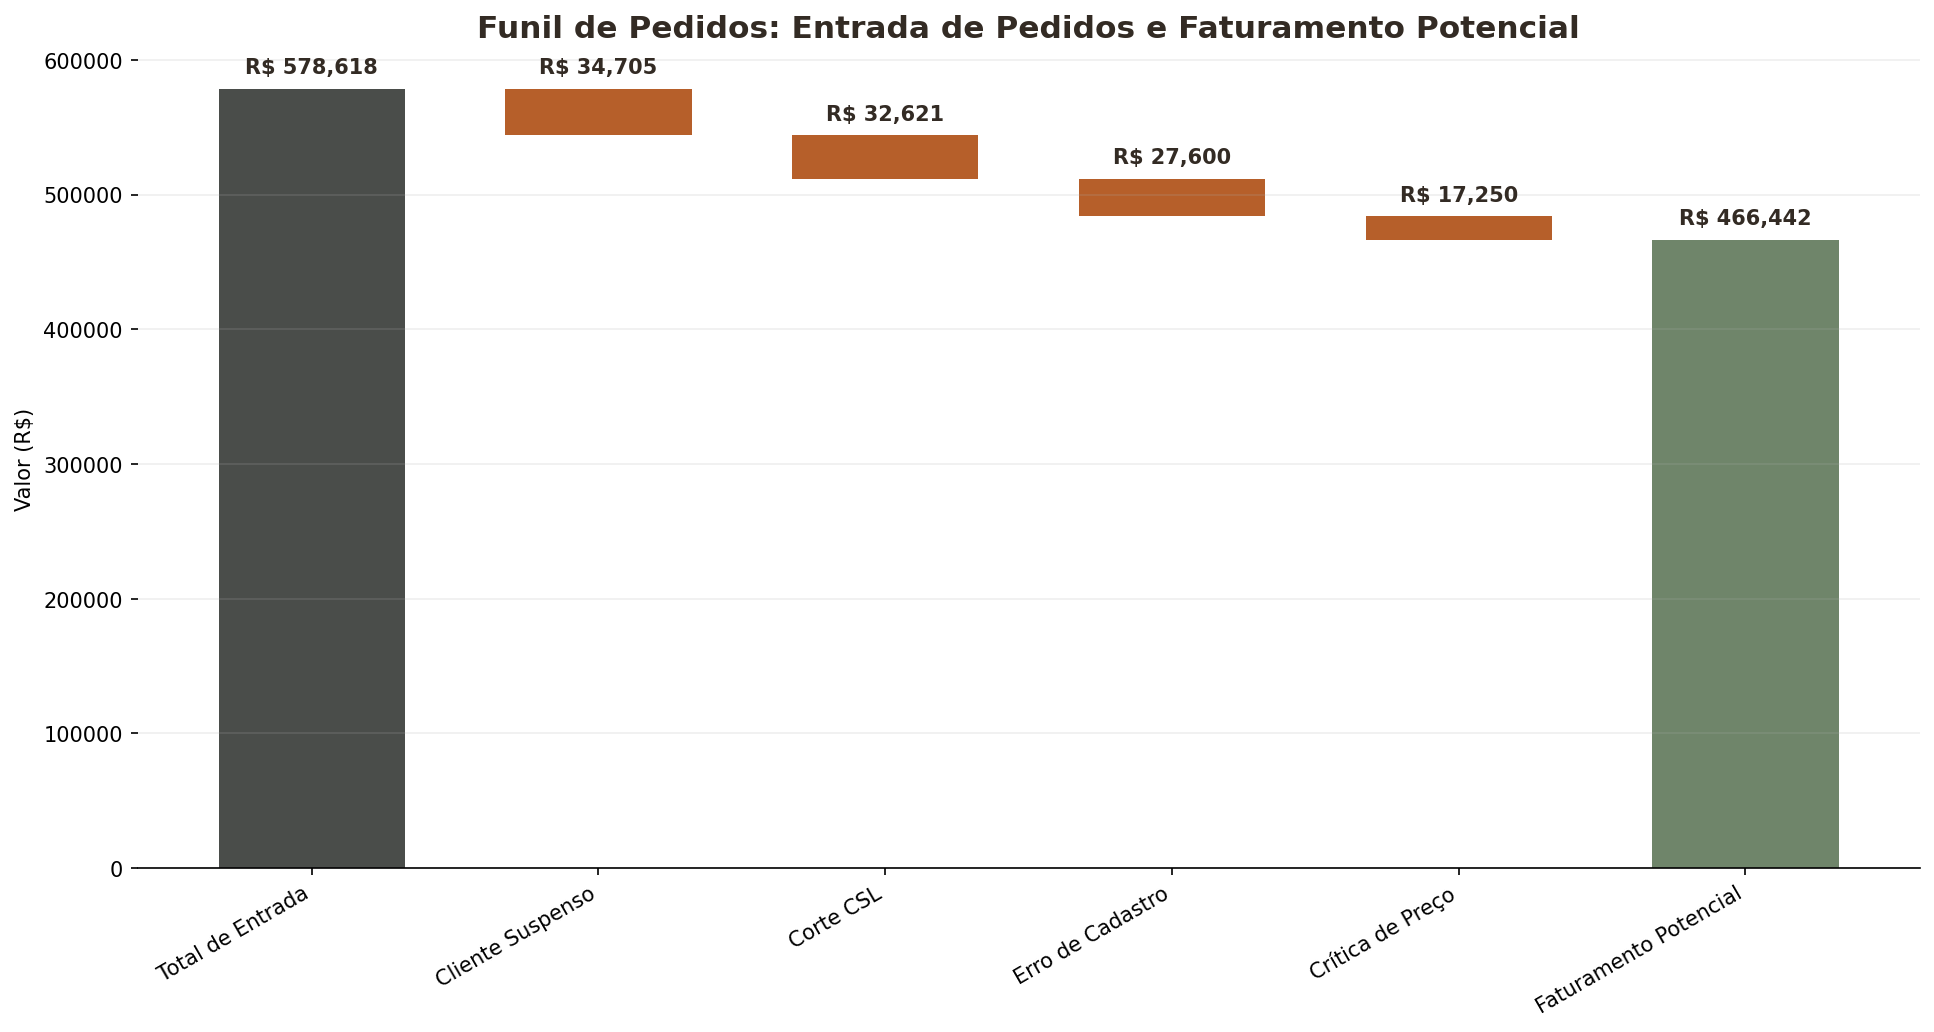

In [ ]:
# WATERFALL
# Valor rejeitado por causa

df_rejeitados = df[
    df["Rejection Reason"] != "Not Rejected"
].copy()

df_rejeitados["Valor_Rejeitado"] = np.where(

    df_rejeitados["Order Status"] == "Partially Confirmed",

    df_rejeitados["Net Value (R$)"]
    -
    (
        df_rejeitados["Net Value (R$)"]
        *
        df_rejeitados["Confirmed Qty"]
        /
        df_rejeitados["Order Qty"].replace(
            0,
            np.nan
        )
    ),

    df_rejeitados["Net Value (R$)"]

)

df_rejeitados["Valor_Rejeitado"] = (
    df_rejeitados["Valor_Rejeitado"]
    .fillna(0)
)

# AGRUPAMENTO DAS CAUSAS
impacto_causas = (
    df_rejeitados
    .groupby("Rejection Reason")["Valor_Rejeitado"]
    .sum()
    .sort_values(
        ascending=False
    )
)

# CONSTRUÇÃO DO WATERFALL
categorias = [
    "Total de Entrada"
]

valores = [
    total_entrada
]

for causa, valor in impacto_causas.items():

    categorias.append(causa)

    valores.append(-valor)


categorias.append(
    "Faturamento Potencial"
)

valores.append(
    faturamento_potencial
)

# POSIÇÃO DAS BARRAS
bases = []
alturas = []

saldo = 0


for i, valor in enumerate(valores):

    # Total inicial

    if i == 0:

        base = 0
        altura = valor
        saldo = valor


    # Total final

    elif i == len(valores) - 1:

        base = 0
        altura = valor


    # Movimentos intermediários

    else:

        base = saldo + valor
        altura = abs(valor)

        saldo += valor


    bases.append(base)
    alturas.append(altura)


cores = []

for categoria in categorias:

    if categoria == "Total de Entrada":

        cores.append(
            COLORS["Total de Entrada"]
        )

    elif categoria == "Faturamento Potencial":

        cores.append(
            COLORS["Confirmado"]
        )

    else:

        cores.append(
            COLORS["Negativo"]
        )


fig_waterfall, ax = plt.subplots(
    figsize=(13, 7)
)


x = np.arange(
    len(categorias)
)


ax.bar(
    x,
    alturas,
    bottom=bases,
    color=cores,
    width=0.65
)

for i, (
    categoria,
    valor,
    base,
    altura
) in enumerate(
    zip(
        categorias,
        valores,
        bases,
        alturas
    )
):

    y = (
        altura + base
        if categoria in [
            "Total de Entrada",
            "Faturamento Potencial"
        ]
        else
        base + altura
    )


    ax.text(
        i,
        y + total_entrada * 0.015,
        f"R$ {abs(valor):,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=COLORS["Texto"]
    )


ax.set_xticks(x)

ax.set_xticklabels(
    categorias,
    rotation=30,
    ha="right"
)


ax.set_ylabel(
    "Valor (R$)"
)


ax.set_title(
    "Funil de Pedidos: Entrada de Pedidos e Faturamento Potencial",
    fontsize=15,
    fontweight="bold",
    color=COLORS["Texto"]
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.grid(
    axis="y",
    alpha=0.2
)


plt.tight_layout()


waterfall_img = figura_para_base64(
    fig_waterfall
)


display(
    HTML(
        f"""
        <img
            src="data:image/png;base64,{waterfall_img}"
            style="
                width:100%;
                max-width:1000px;
                display:block;
                margin:auto;
            "
        >
        """
    )
)

In [ ]:
top_canais_csl = (
    df[df["Rejection Reason"] == "Corte CSL"]
    .groupby("Channel")["Net Value (R$)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [ ]:
csl = df["Rejection Reason"].eq("Corte CSL")

csl_channel = (
    df.groupby("Channel")["Net Value (R$)"]
      .sum()
      .rename("Order Value")
      .to_frame()
)

csl_channel["CSL Value"] = (
    df[csl]
    .groupby("Channel")["Net Value (R$)"]
    .sum()
)

csl_channel["CSL %"] = (
    csl_channel["CSL Value"] /
    csl_channel["Order Value"]
)

In [ ]:
top_clientes_rejeicao = (
    df[
        df["Rejection Reason"] != "Not Rejected"
    ]
    .groupby(
        ["Customer", "Channel"]
    )["Net Value (R$)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [ ]:
total = df["Net Value (R$)"].sum()

faturamento = df["Faturamento"].sum()

impacto_negativo = total - faturamento

percentual_conversao = faturamento / total


In [ ]:
if total != 0:
    conversao = faturamento / total
else:
    conversao = np.nan

In [ ]:
ranking_causas = (
    df[
        df["Rejection Reason"] != "Not Rejected"
    ]
    .groupby("Rejection Reason")["Net Value (R$)"]
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
principal_causa = ranking_causas.index[0]

principal_causa_valor = ranking_causas.iloc[0]

In [ ]:
def gerar_analise(df):

    total = df["Net Value (R$)"].sum()
    faturamento = df["Faturamento"].sum()

    conversao = faturamento / total

    rejeitados = df[
        df["Rejection Reason"] != "Not Rejected"
    ]

    valor_rejeitado = rejeitados["Net Value (R$)"].sum()

    ranking = (
        rejeitados
        .groupby("Rejection Reason")["Net Value (R$)"]
        .sum()
        .sort_values(ascending=False)
    )

    if not ranking.empty:

        principal_causa = ranking.index[0]
        principal_causa_valor = ranking.iloc[0]

    else:

        principal_causa = "Nenhuma"
        principal_causa_valor = 0

    canal_csl = (
        df[df["Rejection Reason"] == "Corte CSL"]
        .groupby("Channel")["Net Value (R$)"]
        .sum()
        .sort_values(ascending=False)
    )

    if len(canal_csl) > 0:

        principal_canal = canal_csl.index[0]
        principal_canal_valor = canal_csl.iloc[0]

    else:

        principal_canal = "Nenhum"
        principal_canal_valor = 0

    texto = f"""
    Dinâmica do Funil de Pedidos

    A entrada de pedidos totalizou R$ {total:,.2f}, 
    com faturamento potencial de R$ {faturamento:,.2f},
    representando uma conversão de {conversao:.1%}.

    Os pedidos com impacto de rejeição representam 
    R$ {valor_rejeitado:,.2f}.

    A principal causa de rejeição foi {principal_causa},
    com impacto de R$ {principal_causa_valor:,.2f}.

    No Corte CSL, o canal com maior impacto foi 
    {principal_canal}, totalizando R$ {principal_canal_valor:,.2f}.
    """

    return texto

In [ ]:
# Checagem dos valores calculados
print(conversao)
print(type(conversao))

0.8061311608003899
<class 'numpy.float64'>


In [ ]:
if pd.isna(conversao):
    alerta_conversao = (
        '<span style="color:#8B3A3A; font-weight:bold;">'
        'Não foi possível calcular a conversão do Order Book.'
        '</span>'
    )

elif conversao < 0.90:
    alerta_conversao = (
        '<span style="color:#B65F2A; font-weight:bold;">'
        'ALERTA: conversão do Order Book abaixo de 90%.'
        '</span>'
    )

elif conversao < 0.95:
    alerta_conversao = (
        '<span style="color:#B5A35A; font-weight:bold;">'
        'ATENÇÃO: conversão do Order Book abaixo de 95%.'
        '</span>'
    )

else:
    alerta_conversao = (
        '<span style="color:#8FA58A; font-weight:bold;">'
        'Conversão do Order Book dentro do esperado.'
        '</span>'
    )

display(HTML(alerta_conversao))

In [ ]:
csl_value = (
    df[df["Rejection Reason"] == "Corte CSL"]["Net Value (R$)"].sum()
)

csl_pct = csl_value / total_entrada if total_entrada != 0 else 0

if csl_pct > 0.10:
    alerta_csl = (
        '<span style="color:#B65F2A; font-weight:bold;">'
        'ALERTA: Corte CSL representa mais de 10% da entrada de pedidos.'
        '</span>'
    )

elif csl_pct > 0.05:
    alerta_csl = (
        '<span style="color:#B5A35A; font-weight:bold;">'
        'ATENÇÃO: Corte CSL acima de 5% da entrada.'
        '</span>'
    )

else:
    alerta_csl = (
        '<span style="color:#8FA58A; font-weight:bold;">'
        'Corte CSL sob controle.'
        '</span>'
    )

display(HTML(alerta_csl))

In [ ]:
#Resumo executivo 

#Participação dos canais no volume de pedidos
canais_valor = (
    df.groupby("Channel")["Net Value (R$)"]
      .sum()
      .sort_values(ascending=False)
)

#Top 3 canais
top_canais = canais_valor.head(3)

#Parte 3: Principal causa de rejeição
if not ranking_causas.empty:
    principal_causa = ranking_causas.index[0]
    principal_causa_valor = ranking_causas.iloc[0]
    principal_causa_pct = principal_causa_valor / total_entrada
else:
    principal_causa = "Nenhuma"
    principal_causa_valor = 0
    principal_causa_pct = 0

#Formatação dos canais
participacao_canais = []

for canal, valor in top_canais.items():
    percentual = valor / total_entrada
    participacao_canais.append(
        f"<b>{canal}</b> ({percentual:.1%})"
    )

canais_texto = ", ".join(participacao_canais)

#Texto executivo
resumo = f"""
<h3 style="color:#4A4038;">Resumo Executivo</h3>

<p style="color:#4A4038; line-height:1.6;">
A entrada de pedidos totalizou 
<b>R$ {total_entrada:,.2f}</b>, com faturamento potencial de 
<b>R$ {faturamento:,.2f}</b>, resultando em uma conversão de 
<b>{conversao:.1%}</b> do Order Book.
</p>

<p style="color:#4A4038; line-height:1.6;">
Os canais com maior representação no valor da entrada de pedidos são:
{canais_texto}.
</p>

<p style="color:#4A4038; line-height:1.6;">
A principal causa de rejeição identificada foi 
<b>{principal_causa}</b>, com impacto de 
<b>R$ {principal_causa_valor:,.2f}</b>, equivalente a 
<b>{principal_causa_pct:.1%}</b> da entrada total de pedidos.
</p>
"""

display(HTML(resumo))

In [ ]:
df.groupby(
    ["Order Status", "Rejection Reason"]
).agg(
    Pedidos=("Sales Order", "count"),
    Valor=("Net Value (R$)", "sum")
).reset_index()

,Order Status,Rejection Reason,Pedidos,Valor
0,Confirmed,Not Rejected,19,338113
1,Partially Confirmed,Corte CSL,4,98130
2,Partially Confirmed,Not Rejected,3,62820
3,Rejected,Cliente Suspenso,2,34705
4,Rejected,Crítica de Preço,1,17250
5,Rejected,Erro de Cadastro,1,27600


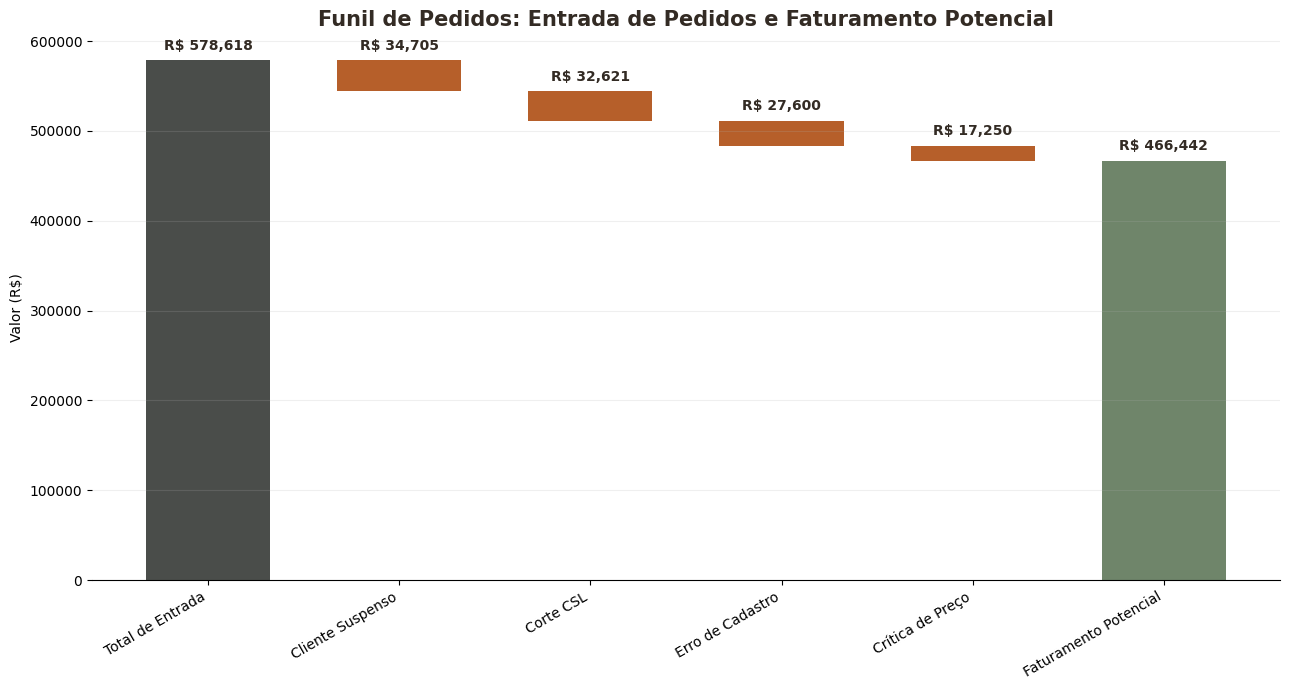

In [ ]:
#Total de entrada de pedidos

total_entrada = df["Net Value (R$)"].sum()

#Identificação dos pedidos rejeitados

df_rejeitados = df[
    df["Rejection Reason"] != "Not Rejected"
].copy()

# Valor efetivamente perdido. Para pedidos parcialmente confirmados, consideramos somente a parcela não confirmada.
## Para pedidos rejeitados integralmente, consideramos o valor total do pedido.

df_rejeitados["Valor_Rejeitado"] = np.where(
    
    df_rejeitados["Order Status"] == "Partially Confirmed",

    df_rejeitados["Net Value (R$)"]
    -
    (
        df_rejeitados["Net Value (R$)"]
        * df_rejeitados["Confirmed Qty"]
        / df_rejeitados["Order Qty"]
    ),

    df_rejeitados["Net Value (R$)"]
)


#Agrupamento das causas

impacto_causas = (
    df_rejeitados
    .groupby("Rejection Reason")["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
)


# Faturamento potencial

total_rejeitado = impacto_causas.sum()

faturamento_potencial = total_entrada - total_rejeitado


# Montagem do waterfall

categorias = ["Total de Entrada"]

valores = [total_entrada]


for causa, valor in impacto_causas.items():

    categorias.append(causa)

    valores.append(-valor)


categorias.append("Faturamento Potencial")

valores.append(faturamento_potencial)


# Posições das barras

bases = []
alturas = []

saldo = 0


for i, valor in enumerate(valores):

    if i == 0:

        # Total inicial
        base = 0
        altura = valor

        saldo = valor


    elif i == len(valores) - 1:

        # Total final
        base = 0
        altura = valor


    else:

        # Movimentos intermediários
        base = saldo + valor
        altura = abs(valor)

        saldo += valor


    bases.append(base)
    alturas.append(altura)


#Cores

cores = []

for categoria, valor in zip(categorias, valores):

    if categoria == "Total de Entrada":

        cores.append(COLORS["Total de Entrada"])


    elif categoria == "Faturamento Potencial":

        cores.append(COLORS["Confirmado"])


    elif categoria in [
        "Corte CSL",
        "Cliente Suspenso",
        "Suspenso",
        "Crítica de Preço",
        "Erro de Cadastro"
    ]:

        cores.append(COLORS["Negativo"])


    else:

        cores.append(COLORS["Rejeitado"])


# Gráfico

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(categorias))

ax.bar(
    x,
    alturas,
    bottom=bases,
    color=cores,
    width=0.65
)

# Valores sobre as barras

for i, (categoria, valor, base, altura) in enumerate(
    zip(categorias, valores, bases, alturas)
):

    if categoria in [
        "Total de Entrada",
        "Faturamento Potencial"
    ]:

        y = altura + base

    else:

        y = base + altura


    ax.text(
        i,
        y + total_entrada * 0.015,
        f"R$ {abs(valor):,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=COLORS["Texto"]
    )


# Formatação

ax.set_xticks(x)

ax.set_xticklabels(
    categorias,
    rotation=30,
    ha="right"
)


ax.set_ylabel("Valor (R$)")


ax.set_title(
    "Funil de Pedidos: Entrada de Pedidos e Faturamento Potencial",
    fontsize=15,
    fontweight="bold",
    color=COLORS["Texto"]
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

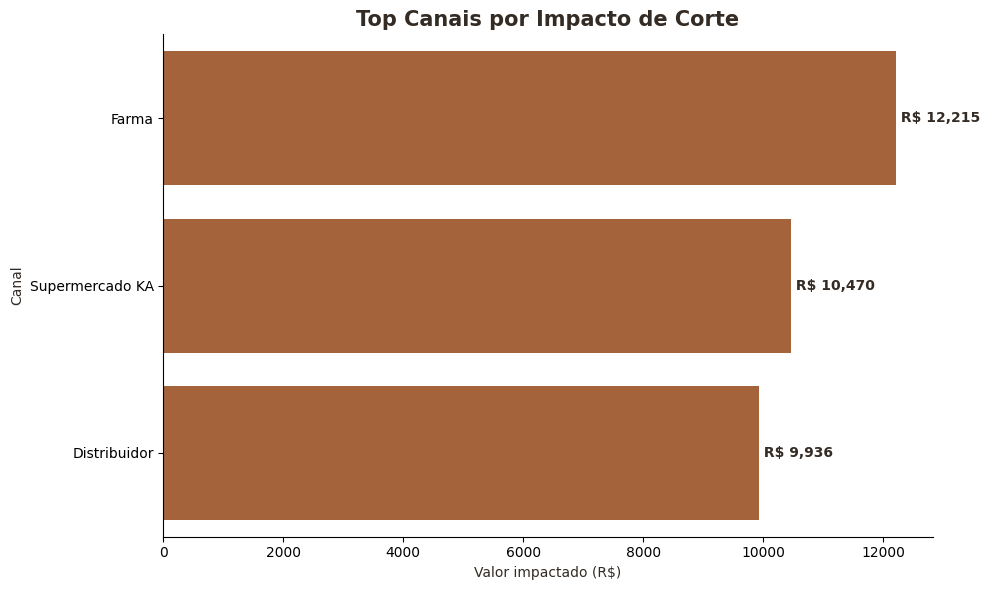

In [ ]:
# Filtra somente Corte CSL
df_csl = df[
    df["Rejection Reason"] == "Corte CSL"
].copy()

# Para pedidos parcialmente confirmados,considera somente o valor não confirmado.
df_csl["Valor_CSL"] = np.where(
    df_csl["Order Status"] == "Partially Confirmed",
    
    df_csl["Net Value (R$)"] -
    (
        df_csl["Net Value (R$)"]
        * df_csl["Confirmed Qty"]
        / df_csl["Order Qty"]
    ),
    
    df_csl["Net Value (R$)"]
)

# Agrupa por canal
top_canais_csl = (
    df_csl
    .groupby("Channel")["Valor_CSL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_canais_csl.values,
    y=top_canais_csl.index,
    color=COLORS["Negativo"]
)

plt.title(
    "Top Canais por Impacto de Corte",
    fontsize=15,
    fontweight="bold",
    color=COLORS["Texto"]
)

plt.xlabel("Valor impactado (R$)", color=COLORS["Texto"])
plt.ylabel("Canal", color=COLORS["Texto"])

# Valores nas barras
for i, valor in enumerate(top_canais_csl.values):
    plt.text(
        valor,
        i,
        f" R$ {valor:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=COLORS["Texto"]
    )

sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
volume_canal = (
    df.groupby("Channel")["Net Value (R$)"]
      .sum()
)

csl_canal = (
    df_csl.groupby("Channel")["Valor_CSL"]
    .sum()
)

csl_por_canal = pd.DataFrame({
    "Entrada de Pedidos": volume_canal,
    "Valor CSL": csl_canal
}).fillna(0)

csl_por_canal["% CSL"] = (
    csl_por_canal["Valor CSL"]
    / csl_por_canal["Entrada de Pedidos"]
)

csl_por_canal = (
    csl_por_canal
    .sort_values("% CSL", ascending=False)
)

csl_por_canal

,Entrada de Pedidos,Valor CSL,% CSL
Channel,,,
Farma,134960,12215.0,0.090508
Supermercado KA,199715,10470.0,0.052425
Distribuidor,226995,9936.0,0.043772
Loja Própria,16948,0.0,0.000000


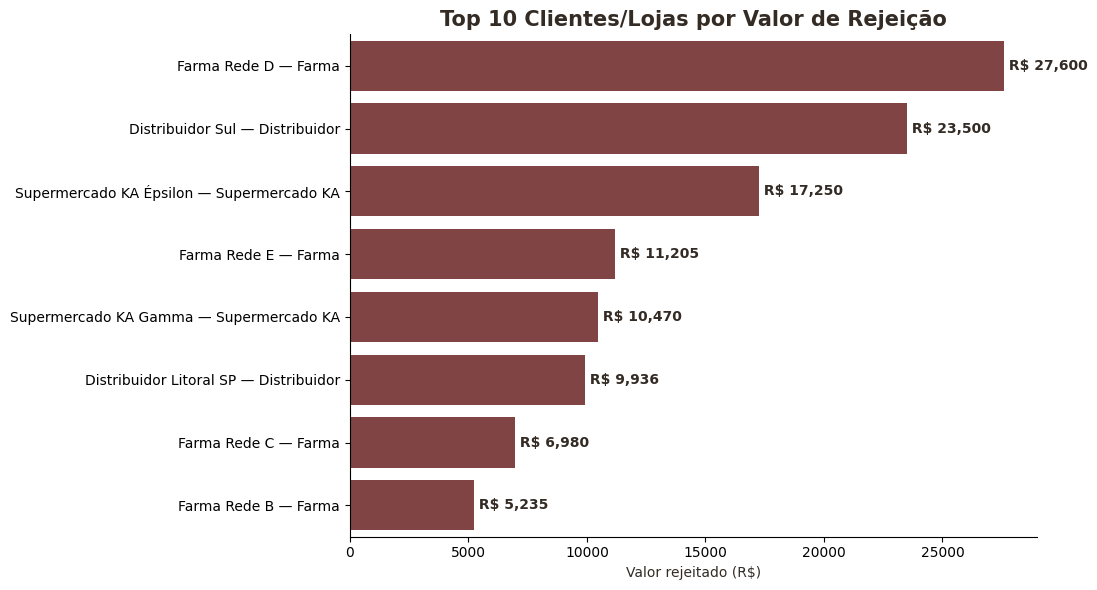

In [ ]:
# Considera somente pedidos rejeitados
df_rejeicao = df[
    df["Rejection Reason"] != "Not Rejected"
].copy()

# Valor efetivamente rejeitado
df_rejeicao["Valor_Rejeitado"] = np.where(
    
    df_rejeicao["Order Status"] == "Partially Confirmed",
    
    df_rejeicao["Net Value (R$)"] -
    (
        df_rejeicao["Net Value (R$)"]
        * df_rejeicao["Confirmed Qty"]
        / df_rejeicao["Order Qty"]
    ),
    
    df_rejeicao["Net Value (R$)"]
)

# Ranking de clientes
top_clientes_rejeicao = (
    df_rejeicao
    .groupby(
        ["Customer", "Channel"]
    )["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


# Gráfico
plt.figure(figsize=(11, 6))

sns.barplot(
    x=top_clientes_rejeicao.values,
    y=[
        f"{cliente} — {canal}"
        for cliente, canal in top_clientes_rejeicao.index
    ],
    color=COLORS["Rejeitado"]
)

plt.title(
    "Top 10 Clientes/Lojas por Valor de Rejeição",
    fontsize=15,
    fontweight="bold",
    color=COLORS["Texto"]
)

plt.xlabel(
    "Valor rejeitado (R$)",
    color=COLORS["Texto"]
)

plt.ylabel(
    "",
    color=COLORS["Texto"]
)

# Valores nas barras
for i, valor in enumerate(top_clientes_rejeicao.values):

    plt.text(
        valor,
        i,
        f" R$ {valor:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=COLORS["Texto"]
    )

sns.despine()

plt.tight_layout()

plt.show()

In [ ]:
top_clientes_lista = (
    top_clientes_rejeicao
    .reset_index()
    .rename(
        columns={
            "Valor_Rejeitado": "Valor Rejeitado"
        }
    )
)

top_clientes_lista

,Customer,Channel,Valor Rejeitado
0,Farma Rede D,Farma,27600.0
1,Distribuidor Sul,Distribuidor,23500.0
2,Supermercado KA Épsilon,Supermercado KA,17250.0
3,Farma Rede E,Farma,11205.0
4,Supermercado KA Gamma,Supermercado KA,10470.0
5,Distribuidor Litoral SP,Distribuidor,9936.0
6,Farma Rede C,Farma,6980.0
7,Farma Rede B,Farma,5235.0


In [ ]:
# GRÁFICOS PARA HTML

fig_csl, ax = plt.subplots(
    figsize=(7, 5)
)

sns.barplot(
    x=top_canais_csl.values,
    y=top_canais_csl.index,
    color=COLORS["Negativo"],
    ax=ax
)

ax.set_title(
    "Top Canais por Impacto de Corte CSL",
    fontsize=13,
    fontweight="bold",
    color=COLORS["Texto"]
)

ax.set_xlabel(
    "Valor impactado (R$)"
)

ax.set_ylabel("")


for i, valor in enumerate(
    top_canais_csl.values
):

    ax.text(
        valor,
        i,
        f" R$ {valor:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=COLORS["Texto"]
    )


sns.despine(
    ax=ax
)

plt.tight_layout()


csl_img = figura_para_base64(
    fig_csl
)


fig_clientes, ax = plt.subplots(
    figsize=(7, 5)
)

clientes_labels = [

    f"{cliente} — {canal}"

    for cliente, canal
    in top_clientes_rejeicao.index

]


sns.barplot(
    x=top_clientes_rejeicao.values,
    y=clientes_labels,
    color=COLORS["Rejeitado"],
    ax=ax
)


ax.set_title(
    "Top Clientes/Lojas por Valor de Rejeição",
    fontsize=13,
    fontweight="bold",
    color=COLORS["Texto"]
)

ax.set_xlabel(
    "Valor rejeitado (R$)"
)

ax.set_ylabel("")


for i, valor in enumerate(
    top_clientes_rejeicao.values
):

    ax.text(
        valor,
        i,
        f" R$ {valor:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=COLORS["Texto"]
    )


sns.despine(
    ax=ax
)

plt.tight_layout()


clientes_img = figura_para_base64(
    fig_clientes
)

fig_skus, ax = plt.subplots(
    figsize=(7, 5)
)

sns.barplot(
    x=top_skus_rejeicao.values,
    y=top_skus_rejeicao.index,
    color=COLORS["Negativo"],
    ax=ax
)


ax.set_title(
    "Top SKUs por Valor de Rejeição",
    fontsize=13,
    fontweight="bold",
    color=COLORS["Texto"]
)

ax.set_xlabel(
    "Valor rejeitado (R$)"
)

ax.set_ylabel("SKU")


for i, valor in enumerate(
    top_skus_rejeicao.values
):

    ax.text(
        valor,
        i,
        f" R$ {valor:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=COLORS["Texto"]
    )


sns.despine(
    ax=ax
)

plt.tight_layout()


skus_img = figura_para_base64(
    fig_skus
)

print(
    "csl_img:",
    len(csl_img),
    "caracteres"
)

print(
    "clientes_img:",
    len(clientes_img),
    "caracteres"
)

print(
    "skus_img:",
    len(skus_img),
    "caracteres"
)

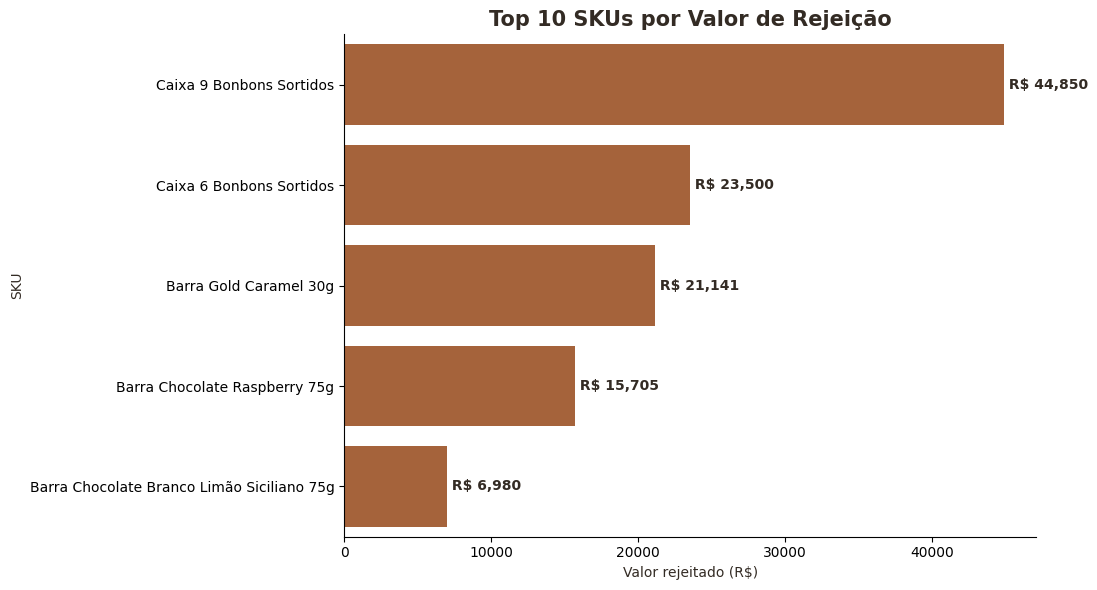

In [ ]:
df_sku_rejeicao = df[
    df["Rejection Reason"] != "Not Rejected"
].copy()

# Valor efetivamente rejeitado

df_sku_rejeicao["Valor_Rejeitado"] = np.where(

    df_sku_rejeicao["Order Status"] == "Partially Confirmed",

    df_sku_rejeicao["Net Value (R$)"]
    -
    (
        df_sku_rejeicao["Net Value (R$)"]
        * df_sku_rejeicao["Confirmed Qty"]
        / df_sku_rejeicao["Order Qty"]
    ),

    df_sku_rejeicao["Net Value (R$)"]
)

# Ranking dos SKUs
top_skus_rejeicao = (
    df_sku_rejeicao
    .groupby("SKU Description")["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Gráfico
plt.figure(figsize=(11, 6))

sns.barplot(
    x=top_skus_rejeicao.values,
    y=top_skus_rejeicao.index,
    color=COLORS["Negativo"]
)

plt.title(
    "Top 10 SKUs por Valor de Rejeição",
    fontsize=15,
    fontweight="bold",
    color=COLORS["Texto"]
)

plt.xlabel(
    "Valor rejeitado (R$)",
    color=COLORS["Texto"]
)

plt.ylabel(
    "SKU",
    color=COLORS["Texto"]
)

# Valores nas barras
for i, valor in enumerate(top_skus_rejeicao.values):

    plt.text(
        valor,
        i,
        f" R$ {valor:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=COLORS["Texto"]
    )


sns.despine()

plt.tight_layout()

plt.show()

In [ ]:
detalhamento_skus = (
    df_sku_rejeicao
    .groupby(
        ["SKU Description", "Rejection Reason"]
    )["Valor_Rejeitado"]
    .sum()
    .reset_index()
    .sort_values(
        "Valor_Rejeitado",
        ascending=False
    )
)

detalhamento_skus.head(15)

,SKU Description,Rejection Reason,Valor_Rejeitado
6,Caixa 9 Bonbons Sortidos,Erro de Cadastro,27600.0
4,Caixa 6 Bonbons Sortidos,Cliente Suspenso,23500.0
5,Caixa 9 Bonbons Sortidos,Crítica de Preço,17250.0
1,Barra Chocolate Raspberry 75g,Corte CSL,15705.0
2,Barra Gold Caramel 30g,Cliente Suspenso,11205.0
3,Barra Gold Caramel 30g,Corte CSL,9936.0
0,Barra Chocolate Branco Limão Siciliano 75g,Corte CSL,6980.0


In [ ]:
# Indicadores gerais
total_entrada = df["Net Value (R$)"].sum()
faturamento_potencial = df["Faturamento"].sum()

conversao = (
    faturamento_potencial / total_entrada
    if total_entrada != 0
    else 0
)

valor_rejeitado = total_entrada - faturamento_potencial

pct_rejeitado = (
    valor_rejeitado / total_entrada
    if total_entrada != 0
    else 0
)


# Pedidos rejeitados
df_rejeicao = df[
    df["Rejection Reason"] != "Not Rejected"
].copy()

# Valor rejeitado por causa
df_rejeicao["Valor_Rejeitado"] = np.where(

    df_rejeicao["Order Status"] == "Partially Confirmed",

    df_rejeicao["Net Value (R$)"]
    -
    (
        df_rejeicao["Net Value (R$)"]
        * df_rejeicao["Confirmed Qty"]
        / df_rejeicao["Order Qty"]
    ),

    df_rejeicao["Net Value (R$)"]
)

ranking_causas = (
    df_rejeicao
    .groupby("Rejection Reason")["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
)

# Principal causa

if not ranking_causas.empty:

    principal_causa = ranking_causas.index[0]
    valor_principal_causa = ranking_causas.iloc[0]

    pct_principal_causa = (
        valor_principal_causa / valor_rejeitado
        if valor_rejeitado != 0
        else 0
    )

else:

    principal_causa = "Nenhuma"
    valor_principal_causa = 0
    pct_principal_causa = 0


# Canal mais impactado
ranking_canais = (
    df_rejeicao
    .groupby("Channel")["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
)


if not ranking_canais.empty:

    principal_canal = ranking_canais.index[0]
    valor_principal_canal = ranking_canais.iloc[0]

    pct_principal_canal = (
        valor_principal_canal / valor_rejeitado
        if valor_rejeitado != 0
        else 0
    )

else:

    principal_canal = "Nenhum"
    valor_principal_canal = 0
    pct_principal_canal = 0


# Cliente mais crítico
ranking_clientes = (
    df_rejeicao
    .groupby(["Customer", "Channel"])["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
)


if not ranking_clientes.empty:

    cliente_critico = ranking_clientes.index[0][0]
    canal_cliente_critico = ranking_clientes.index[0][1]
    valor_cliente_critico = ranking_clientes.iloc[0]

else:

    cliente_critico = "Nenhum"
    canal_cliente_critico = ""
    valor_cliente_critico = 0


# SKU mais crítico
ranking_skus = (
    df_rejeicao
    .groupby("SKU Description")["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
)


if not ranking_skus.empty:

    sku_critico = ranking_skus.index[0]
    valor_sku_critico = ranking_skus.iloc[0]

else:

    sku_critico = "Nenhum"
    valor_sku_critico = 0

# Classificação da criticidade
if pct_rejeitado > 0.10:

    cor_status = COLORS["Rejeitado"]
    status_texto = "nível crítico"

elif pct_rejeitado > 0.05:

    cor_status = COLORS["Negativo"]
    status_texto = "nível de atenção"

else:

    cor_status = COLORS["Confirmado"]
    status_texto = "nível controlado"

# Texto analítico
texto_criticidades = f"""
<h3 style="color:{COLORS["Texto"]};">
Criticidades do Funil de Pedidos
</h3>

<p style="color:{COLORS["Texto"]}; line-height:1.7;">
A entrada de pedidos totalizou 
<b>R$ {total_entrada:,.0f}</b>, com faturamento potencial de 
<b>R$ {faturamento_potencial:,.0f}</b>, resultando em uma conversão de 
<b>{conversao:.1%}</b>.
</p>

<p style="color:{COLORS["Texto"]}; line-height:1.7;">
O valor impactado por rejeições foi de 
<b style="color:{cor_status};">
R$ {valor_rejeitado:,.0f}
</b>,
equivalente a 
<b style="color:{cor_status};">
{pct_rejeitado:.1%}
</b>
da entrada de pedidos, caracterizando um 
<b style="color:{cor_status};">
{status_texto}
</b>
do funil.
</p>

<p style="color:{COLORS["Texto"]}; line-height:1.7;">
A principal causa de rejeição foi 
<b>{principal_causa}</b>,
responsável por 
<b>R$ {valor_principal_causa:,.0f}</b>,
ou 
<b>{pct_principal_causa:.1%}</b>
do valor total rejeitado.
</p>

<p style="color:{COLORS["Texto"]}; line-height:1.7;">
O canal com maior impacto foi 
<b>{principal_canal}</b>,
com 
<b>R$ {valor_principal_canal:,.0f}</b>
em pedidos impactados, representando 
<b>{pct_principal_canal:.1%}</b>
das rejeições.
</p>

<p style="color:{COLORS["Texto"]}; line-height:1.7;">
Entre os clientes, 
<b>{cliente_critico}</b>
é o principal ponto de atenção no canal 
<b>{canal_cliente_critico}</b>,
com impacto de 
<b>R$ {valor_cliente_critico:,.0f}</b>.
</p>

<p style="color:{COLORS["Texto"]}; line-height:1.7;">
O SKU com maior impacto de rejeição é 
<b>{sku_critico}</b>,
com 
<b>R$ {valor_sku_critico:,.0f}</b>
em valor afetado.
</p>
"""

display(HTML(texto_criticidades))

In [ ]:
alertas = []

df_rejeicao = df[
    df["Rejection Reason"] != "Not Rejected"
].copy()


# Valor efetivamente rejeitado. Para pedidos parcialmente confirmados, considera somente a parcela não confirmada.
df_rejeicao["Valor_Rejeitado"] = np.where(

    df_rejeicao["Order Status"] == "Partially Confirmed",

    df_rejeicao["Net Value (R$)"]
    -
    (
        df_rejeicao["Net Value (R$)"]
        * df_rejeicao["Confirmed Qty"]
        / df_rejeicao["Order Qty"]
    ),

    df_rejeicao["Net Value (R$)"]
)

total_entrada = df["Net Value (R$)"].sum()

faturamento_potencial = df["Faturamento"].sum()

valor_rejeitado = df_rejeicao["Valor_Rejeitado"].sum()

conversao = (
    faturamento_potencial / total_entrada
    if total_entrada != 0
    else 0
)

pct_rejeitado = (
    valor_rejeitado / total_entrada
    if total_entrada != 0
    else 0
)

ranking_causas = (
    df_rejeicao
    .groupby("Rejection Reason")["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
)

ranking_canais = (
    df_rejeicao
    .groupby("Channel")["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
)

ranking_clientes = (
    df_rejeicao
    .groupby(["Customer", "Channel"])["Valor_Rejeitado"]
    .sum()
    .sort_values(ascending=False)
)


if conversao < 0.90:

    alertas.append({
        "prioridade": 1,
        "tipo": "Conversão",
        "cor": COLORS["Rejeitado"],
        "texto": (
            f"Conversão do Order Book em "
            f"<b>{conversao:.1%}</b>, com "
            f"<b>R$ {valor_rejeitado:,.0f}</b> "
            f"impactados por rejeições."
        )
    })

elif conversao < 0.95:

    alertas.append({
        "prioridade": 2,
        "tipo": "Conversão",
        "cor": COLORS["Negativo"],
        "texto": (
            f"Conversão do Order Book em "
            f"<b>{conversao:.1%}</b>, abaixo do nível "
            f"de referência de 95%."
        )
    })


csl_value = (
    df_rejeicao[
        df_rejeicao["Rejection Reason"] == "Corte CSL"
    ]["Valor_Rejeitado"].sum()
)

csl_pct = (
    csl_value / total_entrada
    if total_entrada != 0
    else 0
)


if csl_pct > 0.10:

    alertas.append({
        "prioridade": 1,
        "tipo": "Corte CSL",
        "cor": COLORS["Rejeitado"],
        "texto": (
            f"Corte CSL representa "
            f"<b>{csl_pct:.1%}</b> da entrada de pedidos, "
            f"com impacto de <b>R$ {csl_value:,.0f}</b>."
        )
    })

elif csl_pct > 0.05:

    alertas.append({
        "prioridade": 2,
        "tipo": "Corte CSL",
        "cor": COLORS["Negativo"],
        "texto": (
            f"Corte CSL representa "
            f"<b>{csl_pct:.1%}</b> da entrada de pedidos, "
            f"com impacto de <b>R$ {csl_value:,.0f}</b>."
        )
    })


if not ranking_causas.empty:

    principal_causa = ranking_causas.index[0]
    valor_principal_causa = ranking_causas.iloc[0]

    pct_principal_causa = (
        valor_principal_causa / valor_rejeitado
        if valor_rejeitado != 0
        else 0
    )

    alertas.append({
        "prioridade": 2,
        "tipo": "Principal causa",
        "cor": COLORS["Negativo"],
        "texto": (
            f"<b>{principal_causa}</b> é a principal causa de "
            f"rejeição, concentrando "
            f"<b>{pct_principal_causa:.1%}</b> do valor rejeitado "
            f"(<b>R$ {valor_principal_causa:,.0f}</b>)."
        )
    })


if not ranking_canais.empty:

    principal_canal = ranking_canais.index[0]
    valor_principal_canal = ranking_canais.iloc[0]

    pct_principal_canal = (
        valor_principal_canal / valor_rejeitado
        if valor_rejeitado != 0
        else 0
    )

    alertas.append({
        "prioridade": 2,
        "tipo": "Canal crítico",
        "cor": COLORS["Negativo"],
        "texto": (
            f"O canal <b>{principal_canal}</b> concentra "
            f"<b>{pct_principal_canal:.1%}</b> das rejeições, "
            f"com impacto de <b>R$ {valor_principal_canal:,.0f}</b>."
        )
    })


if not ranking_clientes.empty:

    cliente_critico = ranking_clientes.index[0][0]
    canal_cliente_critico = ranking_clientes.index[0][1]
    valor_cliente_critico = ranking_clientes.iloc[0]

    alertas.append({
        "prioridade": 3,
        "tipo": "Cliente crítico",
        "cor": COLORS["Rejeitado"],
        "texto": (
            f"O cliente <b>{cliente_critico}</b>, "
            f"do canal <b>{canal_cliente_critico}</b>, "
            f"apresenta o maior impacto individual de rejeição: "
            f"<b>R$ {valor_cliente_critico:,.0f}</b>."
        )
    })


alertas = sorted(
    alertas,
    key=lambda x: x["prioridade"]
)

alertas_prioritarios = alertas[:3]


html_alertas = f"""
<h3 style="color:{COLORS["Texto"]};">
Alertas Prioritários
</h3>
"""

for alerta in alertas_prioritarios:

    html_alertas += f"""
    <p style="
        color:{COLORS["Texto"]};
        border-left:4px solid {alerta["cor"]};
        padding-left:12px;
        line-height:1.6;
        margin-bottom:14px;
    ">
        <b style="color:{alerta["cor"]};">
            {alerta["tipo"]}
        </b><br>
        {alerta["texto"]}
    </p>
    """

display(HTML(html_alertas))

In [ ]:
print("Colunas da FACT_ORDER_DAILY:")
print(df.columns.tolist())

print("\nAmostra:")
display(df.head())

Colunas da FACT_ORDER_DAILY:
['Snapshot Date', 'Sales Order', 'Item', 'Customer ID', 'Customer', 'Channel', 'Material ID', 'SKU Description', 'Category', 'Plant', 'Requested Date', 'Order Qty', 'Confirmed Qty', 'Open Qty', 'Net Value (R$)', 'Rejection Code', 'Rejection Reason', 'Order Status', 'Faturamento', 'Causa']

Amostra:


,Snapshot Date,Sales Order,Item,Customer ID,Customer,Channel,Material ID,SKU Description,Category,Plant,Requested Date,Order Qty,Confirmed Qty,Open Qty,Net Value (R$),Rejection Code,Rejection Reason,Order Status,Faturamento,Causa
0,2026-08-18,45000001,10,C0001,Mon Minou Shopping Morumbi,Loja Própria,MM30-ML-01,Barra Chocolate ao Leite 30g,Barras,SP01,2026-08-18,200,200,0,2980,—,Not Rejected,Confirmed,2980.0,Not Rejected
1,2026-08-18,45000002,10,C0002,Mon Minou Shopping Eldorado,Loja Própria,MM30-GC-01,Barra Gold Caramel 30g,Barras,SP01,2026-08-18,180,180,0,2880,—,Not Rejected,Confirmed,2880.0,Not Rejected
2,2026-08-18,45000003,10,C0003,Mon Minou Shopping Iguatemi,Loja Própria,MM75-RB-01,Barra Chocolate Raspberry 75g,Barras,SP01,2026-08-19,120,120,0,4188,—,Not Rejected,Confirmed,4188.0,Not Rejected
3,2026-08-18,45000004,10,C0101,Supermercado KA Alpha,Supermercado KA,MM75-60-01,Barra Chocolate 60% 75g,Barras,SP01,2026-08-19,500,500,0,17450,—,Not Rejected,Confirmed,17450.0,Not Rejected
4,2026-08-18,45000005,10,C0102,Supermercado KA Beta,Supermercado KA,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,Barras,SP01,2026-08-20,800,650,150,27920,—,Not Rejected,Partially Confirmed,27920.0,Not Rejected


In [ ]:
#  CENÁRIO MULTI-WAREHOUSE

# Preserva o Plant original do S/4HANA
df["Plant Original"] = df["Plant"]

# Garantir Customer ID como string
df["Customer ID"] = (
    df["Customer ID"]
    .astype(str)
)

#Função para determinar o warehouse
def definir_plant(row):

    canal = str(row["Channel"]).strip()
    customer_id = str(row["Customer ID"])
    if canal == "Loja Própria":

        return "SP01"

    elif canal == "Supermercado Key Account":
        numero = sum(
            ord(char)
            for char in customer_id
        )

        if numero % 2 == 0:
            return "SP01"
        else:
            return "RJ01"

    elif canal == "Distribuidor":

        numero = sum(
            ord(char)
            for char in customer_id
        )

        if numero % 2 == 0:
            return "RJ01"
        else:
            return "MG01"

    elif canal == "Farma":

        numero = sum(
            ord(char)
            for char in customer_id
        )

        if numero % 2 == 0:
            return "MG01"
        else:
            return "SP01"
    else:

        return "SP01"

# 3. Aplicar nova lógica
df["Plant"] = df.apply(
    definir_plant,
    axis=1
)

#Visualizar distribuição

display(
    df[
        [
            "Customer ID",
            "Customer",
            "Channel",
            "Plant Original",
            "Plant"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "Plant",
            "Channel",
            "Customer"
        ]
    )
)

,Customer ID,Customer,Channel,Plant Original,Plant
9,C0202,Distribuidor Litoral SP,Distribuidor,SP01,MG01
11,C0204,Distribuidor Sul,Distribuidor,SP01,MG01
13,C0302,Farma Rede B,Farma,SP01,MG01
15,C0304,Farma Rede D,Farma,SP01,MG01
10,C0203,Distribuidor Interior SP,Distribuidor,SP01,RJ01
8,C0201,Distribuidor SP Capital,Distribuidor,SP01,RJ01
12,C0301,Farma Rede A,Farma,SP01,SP01
14,C0303,Farma Rede C,Farma,SP01,SP01
19,C0305,Farma Rede E,Farma,SP01,SP01
1,C0002,Mon Minou Shopping Eldorado,Loja Própria,SP01,SP01


In [ ]:
display(
    df.groupby(["Plant", "Channel"])
      .agg(
          Pedidos=("Sales Order", "nunique"),
          Valor=("Net Value (R$)", "sum")
      )
      .reset_index()
)

,Plant,Channel,Pedidos,Valor
0,MG01,Distribuidor,4,97200
1,MG01,Farma,4,71690
2,RJ01,Distribuidor,4,129795
3,SP01,Farma,4,63270
4,SP01,Loja Própria,4,16948
5,SP01,Supermercado KA,10,199715


In [ ]:
# VALIDAÇÃO DA DISTRIBUIÇÃO LOGÍSTICA

distribuicao_plant = (
    df
    .groupby(
        ["Plant", "Channel"]
    )
    .agg(
        Pedidos=("Sales Order", "nunique"),
        Valor=("Net Value (R$)", "sum"),
        Open_Qty=("Open Qty", "sum")
    )
    .reset_index()
    .sort_values(
        ["Plant", "Valor"],
        ascending=[True, False]
    )
)

display(distribuicao_plant)

,Plant,Channel,Pedidos,Valor,Open_Qty
0,MG01,Distribuidor,4,97200,1450
1,MG01,Farma,4,71690,550
2,RJ01,Distribuidor,4,129795,0
5,SP01,Supermercado KA,10,199715,800
3,SP01,Farma,4,63270,1100
4,SP01,Loja Própria,4,16948,0


In [ ]:
# FACT_DEMAND_SENSING_DAILY

df_ds_base = df[
    [
        "Snapshot Date",
        "Requested Date",
        "Material ID",
        "SKU Description",
        "Plant",
        "Open Qty",
        "Confirmed Qty"
    ]
].copy()

# Tratamento das datas

df_ds_base["Snapshot Date"] = pd.to_datetime(
    df_ds_base["Snapshot Date"]
)

df_ds_base["Requested Date"] = pd.to_datetime(
    df_ds_base["Requested Date"]
)


# Agregação

df_demand_sensing = (
    df_ds_base
    .groupby(
        [
            "Snapshot Date",
            "Requested Date",
            "Material ID",
            "SKU Description",
            "Plant"
        ],
        as_index=False
    )
    .agg(
        Open_Orders=("Open Qty", "sum"),
        Confirmed_Orders=("Confirmed Qty", "sum")
    )
)


# Forecast Base: AMOSTRA. Pedidos confirmados + abertos como sinal operacional para construir um forecast sintético.

df_demand_sensing["Base Forecast Qty"] = (
    df_demand_sensing["Confirmed_Orders"]
    +
    df_demand_sensing["Open_Orders"] * 0.70
)


# Demand Sensing Forecast: AMOSTRA. Simulação de aceleração/queda da demanda. A variação é determinística para facilitar a reprodução do case.

df_demand_sensing["DS_Factor"] = np.where(
    df_demand_sensing["Open_Orders"]
    >
    df_demand_sensing["Open_Orders"].median(),

    1.10,

    0.95
)


df_demand_sensing["Demand Sensing Forecast Qty"] = (
    df_demand_sensing["Base Forecast Qty"]
    *
    df_demand_sensing["DS_Factor"]
)


# Variação Demand Sensing x Forecast

df_demand_sensing["Forecast Variation %"] = np.where(

    df_demand_sensing["Base Forecast Qty"] != 0,

    (
        df_demand_sensing["Demand Sensing Forecast Qty"]
        /
        df_demand_sensing["Base Forecast Qty"]
    ) - 1,

    0
)

# Seleção das colunas finais
df_demand_sensing = df_demand_sensing[
    [
        "Snapshot Date",
        "Requested Date",
        "Material ID",
        "SKU Description",
        "Plant",
        "Open_Orders",
        "Confirmed_Orders",
        "Base Forecast Qty",
        "Demand Sensing Forecast Qty",
        "Forecast Variation %"
    ]
].copy()

# Visualização
display(
    df_demand_sensing.head(10)
)

,Snapshot Date,Requested Date,Material ID,SKU Description,Plant,Open_Orders,Confirmed_Orders,Base Forecast Qty,Demand Sensing Forecast Qty,Forecast Variation %
0,2026-08-18,2026-08-18,MM09-BN-01,Caixa 9 Bonbons Sortidos,SP01,250,100,275.0,302.5,0.10
1,2026-08-18,2026-08-18,MM30-GC-01,Barra Gold Caramel 30g,SP01,900,180,810.0,891.0,0.10
2,2026-08-18,2026-08-18,MM30-ML-01,Barra Chocolate ao Leite 30g,SP01,0,2400,2400.0,2280.0,-0.05
3,2026-08-18,2026-08-18,MM75-RB-01,Barra Chocolate Raspberry 75g,SP01,300,700,910.0,1001.0,0.10
4,2026-08-18,2026-08-19,MM30-ML-01,Barra Chocolate ao Leite 30g,MG01,0,800,800.0,760.0,-0.05
5,2026-08-18,2026-08-19,MM30-ML-01,Barra Chocolate ao Leite 30g,SP01,0,1600,1600.0,1520.0,-0.05
6,2026-08-18,2026-08-19,MM30-RB-01,Barra Chocolate Raspberry 30g,MG01,0,1200,1200.0,1140.0,-0.05
7,2026-08-18,2026-08-19,MM75-60-01,Barra Chocolate 60% 75g,SP01,0,500,500.0,475.0,-0.05
8,2026-08-18,2026-08-19,MM75-GC-01,Barra Gold Caramel 75g,SP01,100,300,370.0,407.0,0.10
9,2026-08-18,2026-08-19,MM75-RB-01,Barra Chocolate Raspberry 75g,SP01,0,120,120.0,114.0,-0.05


In [ ]:
# FACT_WAREHOUSE_CAPACITY_DAILY
df_wh_base = df[
    [
        "Snapshot Date",
        "Plant",
        "Open Qty",
        "Confirmed Qty"
    ]
].copy()


df_wh_base["Snapshot Date"] = pd.to_datetime(
    df_wh_base["Snapshot Date"]
)

# CARGA LOGÍSTICA

df_warehouse = (
    df_wh_base
    .groupby(
        [
            "Snapshot Date",
            "Plant"
        ],
        as_index=False
    )
    .agg(
        Open_Orders=("Open Qty", "sum"),
        Confirmed_Orders=("Confirmed Qty", "sum")
    )
)

# CARGA TOTAL ATUAL
df_warehouse["Current Load"] = (
    df_warehouse["Confirmed_Orders"]
    +
    df_warehouse["Open_Orders"]
)

# CAPACIDADE SINTÉTICA
# A capacidade representa a capacidade instalada estimada do warehouse.
# Utilizamos 85% como referência de operação normal.Assim, a carga atual não ultrapassa artificialmente 100% apenas por causa da fórmula.

capacidade_por_plant = (
    df_warehouse
    .groupby("Plant")["Current Load"]
    .max()
    / 0.85
)


df_warehouse["Total Capacity"] = (
    df_warehouse["Plant"]
    .map(capacidade_por_plant)
)


# OCUPAÇÃO ATUAL
df_warehouse["Occupied Capacity"] = (
    df_warehouse["Current Load"]
)

# CAPACIDADE DISPONÍVEL
df_warehouse["Available Capacity"] = (
    df_warehouse["Total Capacity"]
    -
    df_warehouse["Occupied Capacity"]
)

# UTILIZAÇÃO ATUAL

df_warehouse["Utilization %"] = np.where(

    df_warehouse["Total Capacity"] > 0,

    df_warehouse["Occupied Capacity"]
    /
    df_warehouse["Total Capacity"],

    0
)
# DEMAND SENSING
ds_por_plant = (
    df_demand_sensing
    .groupby(
        [
            "Snapshot Date",
            "Plant"
        ],
        as_index=False
    )["Demand Sensing Forecast Qty"]
    .sum()
)


df_warehouse = df_warehouse.merge(
    ds_por_plant,
    on=[
        "Snapshot Date",
        "Plant"
    ],
    how="left"
)


df_warehouse[
    "Demand Sensing Forecast Qty"
] = (
    df_warehouse[
        "Demand Sensing Forecast Qty"
    ]
    .fillna(0)
)

# OCUPAÇÃO PROJETADA
# Mede somente o incremento do Demand Sensing em relação ao volume atualmente aberto.

df_warehouse["Demand Increment"] = (

    df_warehouse["Demand Sensing Forecast Qty"]
    -
    df_warehouse["Open_Orders"]

)

# Não permite incremento negativo
df_warehouse["Demand Increment"] = (
    df_warehouse["Demand Increment"]
    .clip(lower=0)
)

# Consideramos 50% do incremento como pressão adicional sobre a capacidade logística.

df_warehouse["Projected Occupancy"] = (

    df_warehouse["Occupied Capacity"]

    +

    df_warehouse["Demand Increment"] * 0.50

)# UTILIZAÇÃO PROJETADA

df_warehouse["Projected Utilization %"] = np.where(

    df_warehouse["Total Capacity"] > 0,

    df_warehouse["Projected Occupancy"]
    /
    df_warehouse["Total Capacity"],

    0
)

# 10. STATUS
# ==========================================

df_warehouse["Capacity Status"] = np.select(

    [
        df_warehouse["Projected Utilization %"] >= 0.95,

        df_warehouse["Projected Utilization %"] >= 0.85
    ],

    [
        "Critical",

        "Attention"
    ],

    default="Normal"
)

# COLUNAS FINAIS

df_warehouse = df_warehouse[
    [
        "Snapshot Date",
        "Plant",
        "Open_Orders",
        "Confirmed_Orders",
        "Total Capacity",
        "Occupied Capacity",
        "Available Capacity",
        "Demand Sensing Forecast Qty",
        "Demand Increment",
        "Projected Occupancy",
        "Utilization %",
        "Projected Utilization %",
        "Capacity Status"
    ]
].copy()

display(
    df_warehouse
)

,Snapshot Date,Plant,Open_Orders,Confirmed_Orders,Total Capacity,Occupied Capacity,Available Capacity,Demand Sensing Forecast Qty,Demand Increment,Projected Occupancy,Utilization %,Projected Utilization %,Capacity Status
0,2026-08-18,MG01,2000,4800,8000.000000,6800,1200.000000,6400.0,4400.0,9000.00,0.85,1.125000,Critical
1,2026-08-18,RJ01,0,4000,4705.882353,4000,705.882353,3800.0,3800.0,5900.00,0.85,1.253750,Critical
2,2026-08-18,SP01,1900,8600,12352.941176,10500,1852.941176,9982.5,8082.5,14541.25,0.85,1.177149,Critical


In [ ]:
display(
    df_warehouse[
        [
            "Plant",
            "Utilization %",
            "Projected Utilization %",
            "Capacity Status"
        ]
    ]
)

,Plant,Utilization %,Projected Utilization %,Capacity Status
0,MG01,0.85,1.125000,Critical
1,RJ01,0.85,1.253750,Critical
2,SP01,0.85,1.177149,Critical


In [ ]:
# FACT_SUPPLY_RISK_DAILY
# PEDIDOS

df_order_risk = df.copy()

df_order_risk["Snapshot Date"] = pd.to_datetime(
    df_order_risk["Snapshot Date"]
)

df_order_risk["Requested Date"] = pd.to_datetime(
    df_order_risk["Requested Date"]
)

# VALOR REJEITADO

df_order_risk["Rejected Value"] = np.where(

    df_order_risk["Order Status"] == "Partially Confirmed",

    df_order_risk["Net Value (R$)"]
    -
    (
        df_order_risk["Net Value (R$)"]
        * df_order_risk["Confirmed Qty"]
        / df_order_risk["Order Qty"].replace(0, np.nan)
    ),

    np.where(
        df_order_risk["Rejection Reason"] != "Not Rejected",

        df_order_risk["Net Value (R$)"],

        0
    )
)

df_order_risk["Rejected Value"] = (
    df_order_risk["Rejected Value"]
    .fillna(0)
)

# AGREGAÇÃO DOS PEDIDOS

order_risk = (
    df_order_risk
    .groupby(
        [
            "Snapshot Date",
            "Material ID",
            "SKU Description",
            "Plant"
        ],
        as_index=False
    )
    .agg(
        Order_Qty=("Order Qty", "sum"),
        Confirmed_Qty=("Confirmed Qty", "sum"),
        Open_Qty=("Open Qty", "sum"),
        Net_Value=("Net Value (R$)", "sum"),
        Rejected_Value=("Rejected Value", "sum")
    )
)


# DEMAND SENSING

ds_risk = (
    df_demand_sensing
    .groupby(
        [
            "Snapshot Date",
            "Material ID",
            "SKU Description",
            "Plant"
        ],
        as_index=False
    )
    .agg(
        Base_Forecast_Qty=(
            "Base Forecast Qty",
            "sum"
        ),

        Demand_Sensing_Forecast_Qty=(
            "Demand Sensing Forecast Qty",
            "sum"
        )
    )
)

# PEDIDOS + DEMAND SENSING

df_supply_risk = order_risk.merge(

    ds_risk,

    on=[
        "Snapshot Date",
        "Material ID",
        "SKU Description",
        "Plant"
    ],

    how="left"
)

# TRATAMENTO DO DEMAND SENSING

df_supply_risk[
    [
        "Base_Forecast_Qty",
        "Demand_Sensing_Forecast_Qty"
    ]
] = (
    df_supply_risk[
        [
            "Base_Forecast_Qty",
            "Demand_Sensing_Forecast_Qty"
        ]
    ]
    .fillna(0)
)


# VARIAÇÃO DO DEMAND SENSING

df_supply_risk["Forecast_Variation_%"] = np.where(

    df_supply_risk["Base_Forecast_Qty"] != 0,

    (
        df_supply_risk["Demand_Sensing_Forecast_Qty"]
        /
        df_supply_risk["Base_Forecast_Qty"]
    ) - 1,

    0
)

# WAREHOUSE CAPACITY

warehouse_risk = (
    df_warehouse[
        [
            "Snapshot Date",
            "Plant",
            "Total Capacity",
            "Occupied Capacity",
            "Available Capacity",
            "Projected Occupancy",
            "Utilization %",
            "Projected Utilization %",
            "Capacity Status"
        ]
    ]
    .drop_duplicates(
        [
            "Snapshot Date",
            "Plant"
        ]
    )
)

# WAREHOUSE

df_supply_risk = df_supply_risk.merge(

    warehouse_risk,

    on=[
        "Snapshot Date",
        "Plant"
    ],

    how="left"
)

# RISCO DE DEMANDA

df_supply_risk["Demand Risk"] = np.select(

    [
        df_supply_risk["Forecast_Variation_%"] >= 0.10,

        df_supply_risk["Forecast_Variation_%"] >= 0.05
    ],

    [
        "Critical",

        "Attention"
    ],

    default="Normal"
)

# RISCO DE CAPACIDADE

df_supply_risk["Capacity Risk"] = np.select(

    [
        df_supply_risk["Projected Utilization %"] >= 0.95,

        df_supply_risk["Projected Utilization %"] >= 0.85
    ],

    [
        "Critical",

        "Attention"
    ],

    default="Normal"
)


# RISK SCORE
df_supply_risk["Risk Score"] = (

    np.where(
        df_supply_risk["Demand Risk"] == "Critical",
        2,

        np.where(
            df_supply_risk["Demand Risk"] == "Attention",
            1,
            0
        )
    )

    +

    np.where(
        df_supply_risk["Capacity Risk"] == "Critical",
        2,

        np.where(
            df_supply_risk["Capacity Risk"] == "Attention",
            1,
            0
        )
    )
)


# CLASSIFICAÇÃO FINAL

df_supply_risk["Supply Risk"] = np.select(

    [
        df_supply_risk["Risk Score"] >= 3,

        df_supply_risk["Risk Score"] == 2,

        df_supply_risk["Risk Score"] == 1
    ],

    [
        "Critical",

        "Attention",

        "Monitor"
    ],

    default="Normal"
)


# ORDENAÇÃO POR RISCO

df_supply_risk = (
    df_supply_risk
    .sort_values(
        [
            "Risk Score",
            "Rejected_Value"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


# VISUALIZAÇÃO
display(
    df_supply_risk.head(20)
)

,Snapshot Date,Material ID,SKU Description,Plant,Order_Qty,Confirmed_Qty,Open_Qty,Net_Value,Rejected_Value,Base_Forecast_Qty,...,Occupied Capacity,Available Capacity,Projected Occupancy,Utilization %,Projected Utilization %,Capacity Status,Demand Risk,Capacity Risk,Risk Score,Supply Risk
0,2026-08-18,MM09-BN-01,Caixa 9 Bonbons Sortidos,MG01,400,0,400,27600,27600.0,280.0,...,6800,1200.000000,9000.00,0.85,1.125000,Critical,Critical,Critical,4,Critical
1,2026-08-18,MM06-BN-01,Caixa 6 Bonbons Sortidos,MG01,500,0,500,23500,23500.0,350.0,...,6800,1200.000000,9000.00,0.85,1.125000,Critical,Critical,Critical,4,Critical
2,2026-08-18,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,SP01,1400,1050,350,48860,12215.0,1295.0,...,10500,1852.941176,14541.25,0.85,1.177149,Critical,Critical,Critical,4,Critical
3,2026-08-18,MM30-GC-01,Barra Gold Caramel 30g,SP01,1080,180,900,14085,11205.0,810.0,...,10500,1852.941176,14541.25,0.85,1.177149,Critical,Critical,Critical,4,Critical
4,2026-08-18,MM30-GC-01,Barra Gold Caramel 30g,MG01,2000,1200,800,24840,9936.0,1760.0,...,6800,1200.000000,9000.00,0.85,1.125000,Critical,Critical,Critical,4,Critical
5,2026-08-18,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,MG01,600,450,150,20940,5235.0,555.0,...,6800,1200.000000,9000.00,0.85,1.125000,Critical,Critical,Critical,4,Critical
6,2026-08-18,MM75-RB-01,Barra Chocolate Raspberry 75g,MG01,500,350,150,17450,5235.0,455.0,...,6800,1200.000000,9000.00,0.85,1.125000,Critical,Critical,Critical,4,Critical
7,2026-08-18,MM75-GC-01,Barra Gold Caramel 75g,SP01,400,300,100,13960,3490.0,370.0,...,10500,1852.941176,14541.25,0.85,1.177149,Critical,Critical,Critical,4,Critical
8,2026-08-18,MM75-RB-01,Barra Chocolate Raspberry 75g,SP01,1120,820,300,39088,10470.0,1030.0,...,10500,1852.941176,14541.25,0.85,1.177149,Critical,Attention,Critical,3,Critical
9,2026-08-18,MM09-BN-01,Caixa 9 Bonbons Sortidos,SP01,650,400,250,44850,17250.0,575.0,...,10500,1852.941176,14541.25,0.85,1.177149,Critical,Normal,Critical,2,Attention


In [ ]:
display(
    df_supply_risk[
        [
            "Material ID",
            "SKU Description",
            "Plant",
            "Forecast_Variation_%",
            "Projected Utilization %",
            "Demand Risk",
            "Capacity Risk",
            "Risk Score",
            "Supply Risk"
        ]
    ]
    .head(20)
)

,Material ID,SKU Description,Plant,Forecast_Variation_%,Projected Utilization %,Demand Risk,Capacity Risk,Risk Score,Supply Risk
0,MM09-BN-01,Caixa 9 Bonbons Sortidos,MG01,0.100000,1.125000,Critical,Critical,4,Critical
1,MM06-BN-01,Caixa 6 Bonbons Sortidos,MG01,0.100000,1.125000,Critical,Critical,4,Critical
2,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,SP01,0.100000,1.177149,Critical,Critical,4,Critical
3,MM30-GC-01,Barra Gold Caramel 30g,SP01,0.100000,1.177149,Critical,Critical,4,Critical
4,MM30-GC-01,Barra Gold Caramel 30g,MG01,0.100000,1.125000,Critical,Critical,4,Critical
5,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,MG01,0.100000,1.125000,Critical,Critical,4,Critical
6,MM75-RB-01,Barra Chocolate Raspberry 75g,MG01,0.100000,1.125000,Critical,Critical,4,Critical
7,MM75-GC-01,Barra Gold Caramel 75g,SP01,0.100000,1.177149,Critical,Critical,4,Critical
8,MM75-RB-01,Barra Chocolate Raspberry 75g,SP01,0.082524,1.177149,Attention,Critical,3,Critical
9,MM09-BN-01,Caixa 9 Bonbons Sortidos,SP01,0.021739,1.177149,Normal,Critical,2,Attention


In [ ]:
# TABELA UNIFICADA PARA TABLEAU

df_tableau = df.copy()


df_tableau["Snapshot Date"] = pd.to_datetime(
    df_tableau["Snapshot Date"]
)

df_tableau["Requested Date"] = pd.to_datetime(
    df_tableau["Requested Date"]
)

ds_tableau = (
    df_demand_sensing[
        [
            "Snapshot Date",
            "Requested Date",
            "Material ID",
            "Plant",
            "Base Forecast Qty",
            "Demand Sensing Forecast Qty",
            "Forecast Variation %"
        ]
    ]
    .drop_duplicates(
        [
            "Snapshot Date",
            "Requested Date",
            "Material ID",
            "Plant"
        ]
    )
)

df_tableau = df_tableau.merge(

    ds_tableau,

    on=[
        "Snapshot Date",
        "Requested Date",
        "Material ID",
        "Plant"
    ],

    how="left",

    validate="many_to_one"
)

warehouse_tableau = (
    df_warehouse[
        [
            "Snapshot Date",
            "Plant",
            "Total Capacity",
            "Occupied Capacity",
            "Available Capacity",
            "Utilization %",
            "Demand Sensing Forecast Qty",
            "Projected Occupancy",
            "Projected Utilization %",
            "Capacity Status"
        ]
    ]
    .drop_duplicates(
        [
            "Snapshot Date",
            "Plant"
        ]
    )
)

df_tableau = df_tableau.merge(

    warehouse_tableau,

    on=[
        "Snapshot Date",
        "Plant"
    ],

    how="left",

    validate="many_to_one",

    suffixes=("", "_Warehouse")
)

supply_tableau = (
    df_supply_risk[
        [
            "Snapshot Date",
            "Material ID",
            "SKU Description",
            "Plant",
            "Rejected_Value",
            "Forecast_Variation_%",
            "Demand Risk",
            "Capacity Risk",
            "Risk Score",
            "Supply Risk"
        ]
    ]
    .drop_duplicates(
        [
            "Snapshot Date",
            "Material ID",
            "SKU Description",
            "Plant"
        ]
    )
)

df_tableau = df_tableau.merge(

    supply_tableau,

    on=[
        "Snapshot Date",
        "Material ID",
        "SKU Description",
        "Plant"
    ],

    how="left",

    validate="many_to_one"
)

colunas_numericas = [
    "Base Forecast Qty",
    "Demand Sensing Forecast Qty",
    "Forecast Variation %",
    "Total Capacity",
    "Occupied Capacity",
    "Available Capacity",
    "Utilization %",
    "Projected Occupancy",
    "Projected Utilization %",
    "Rejected_Value",
    "Risk Score"
]

for coluna in colunas_numericas:

    if coluna in df_tableau.columns:

        df_tableau[coluna] = (
            df_tableau[coluna]
            .fillna(0)
        )

df_tableau = df_tableau.rename(
    columns={
        "Rejected_Value": "Rejected Value (R$)",
        "Forecast_Variation_%": "Forecast Variation %",
        "Risk Score": "Supply Risk Score"
    }
)

df_tableau = (
    df_tableau
    .sort_values(
        [
            "Snapshot Date",
            "Sales Order",
            "Item"
        ]
    )
    .reset_index(drop=True)
)

print(
    "Linhas da FACT_ORDER_DAILY:",
    len(df)
)

print(
    "Linhas da FACT_SALES_ORDER_ANALYTICS:",
    len(df_tableau)
)

print(
    "Colunas:",
    len(df_tableau.columns)
)

display(
    df_tableau.head(10)
)

Linhas da FACT_ORDER_DAILY: 30
Linhas da FACT_SALES_ORDER_ANALYTICS: 30
Colunas: 38


,Snapshot Date,Sales Order,Item,Customer ID,Customer,Channel,Material ID,SKU Description,Category,Plant,...,Demand Sensing Forecast Qty_Warehouse,Projected Occupancy,Projected Utilization %,Capacity Status,Rejected Value (R$),Forecast Variation %,Demand Risk,Capacity Risk,Supply Risk Score,Supply Risk
0,2026-08-18,45000001,10,C0001,Mon Minou Shopping Morumbi,Loja Própria,MM30-ML-01,Barra Chocolate ao Leite 30g,Barras,SP01,...,9982.5,14541.25,1.177149,Critical,0.0,-0.050000,Normal,Critical,2,Attention
1,2026-08-18,45000002,10,C0002,Mon Minou Shopping Eldorado,Loja Própria,MM30-GC-01,Barra Gold Caramel 30g,Barras,SP01,...,9982.5,14541.25,1.177149,Critical,11205.0,0.100000,Critical,Critical,4,Critical
2,2026-08-18,45000003,10,C0003,Mon Minou Shopping Iguatemi,Loja Própria,MM75-RB-01,Barra Chocolate Raspberry 75g,Barras,SP01,...,9982.5,14541.25,1.177149,Critical,10470.0,0.082524,Attention,Critical,3,Critical
3,2026-08-18,45000004,10,C0101,Supermercado KA Alpha,Supermercado KA,MM75-60-01,Barra Chocolate 60% 75g,Barras,SP01,...,9982.5,14541.25,1.177149,Critical,0.0,-0.050000,Normal,Critical,2,Attention
4,2026-08-18,45000005,10,C0102,Supermercado KA Beta,Supermercado KA,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,Barras,SP01,...,9982.5,14541.25,1.177149,Critical,12215.0,0.100000,Critical,Critical,4,Critical
5,2026-08-18,45000006,10,C0103,Supermercado KA Gamma,Supermercado KA,MM75-RB-01,Barra Chocolate Raspberry 75g,Barras,SP01,...,9982.5,14541.25,1.177149,Critical,10470.0,0.082524,Attention,Critical,3,Critical
6,2026-08-18,45000007,10,C0104,Supermercado KA Delta,Supermercado KA,MM09-BN-01,Caixa 9 Bonbons Sortidos,Bonbons,SP01,...,9982.5,14541.25,1.177149,Critical,17250.0,0.021739,Normal,Critical,2,Attention
7,2026-08-18,45000008,10,C0105,Supermercado KA Épsilon,Supermercado KA,MM09-BN-01,Caixa 9 Bonbons Sortidos,Bonbons,SP01,...,9982.5,14541.25,1.177149,Critical,17250.0,0.021739,Normal,Critical,2,Attention
8,2026-08-18,45000009,10,C0201,Distribuidor SP Capital,Distribuidor,MM30-ML-01,Barra Chocolate ao Leite 30g,Barras,RJ01,...,3800.0,5900.00,1.253750,Critical,0.0,-0.050000,Normal,Critical,2,Attention
9,2026-08-18,45000010,10,C0202,Distribuidor Litoral SP,Distribuidor,MM30-GC-01,Barra Gold Caramel 30g,Barras,MG01,...,6400.0,9000.00,1.125000,Critical,9936.0,0.100000,Critical,Critical,4,Critical


In [ ]:
duplicados = (
    df_tableau
    .duplicated(
        subset=[
            "Snapshot Date",
            "Sales Order",
            "Item"
        ]
    )
    .sum()
)

print(
    f"Pedidos/itens duplicados: {duplicados}"
)

Pedidos/itens duplicados: 0


In [ ]:
arquivo_csv = "FACT_SALES_ORDER_ANALYTICS.csv"

df_tableau.to_csv(
    arquivo_csv,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)

print(
    f"CSV gerado: {os.path.abspath(arquivo_csv)}"
)

CSV gerado: c:\Users\sylfe\OneDrive\Documentos\DADOS\orders_funnel_soe\FACT_SALES_ORDER_ANALYTICS.csv


In [ ]:
TABLEAU_URL = (
    "https://public.tableau.com/app/profile/sylferreira/viz/S4HANASalesOrderAnalytics/OrdersFunnel"
)

In [ ]:

html_tableau = f"""
<div style="
    margin-top:30px;
    margin-bottom:30px;
    padding:20px;
    background:#F7F3ED;
    border:1px solid #E6DED2;
    text-align:center;
">

<h3 style="
    margin:0 0 8px 0;
    color:{COLORS["Texto"]};
">

Análises Complementares

</h3>

<p style="
    margin:0 0 15px 0;
    color:#777;
    font-size:13px;
">

Explore o Order Book, clientes, SKUs, Demand Sensing
e capacidade logística no Tableau Public.

</p>

<a
    href="{TABLEAU_URL}"
    target="_blank"
    style="
        display:inline-block;
        background:{COLORS["Confirmado"]};
        color:white;
        padding:12px 24px;
        text-decoration:none;
        font-weight:bold;
        font-size:13px;
        border-radius:4px;
    "
>

Abrir Dashboard no Tableau Public

</a>

</div>
"""

In [ ]:
# TOP SUPPLY RISKS

top_supply_risks = (
    df_supply_risk[
        df_supply_risk["Supply Risk"].isin(
            ["Critical", "Attention"]
        )
    ]
    .sort_values(
        [
            "Risk Score",
            "Rejected_Value"
        ],
        ascending=[False, False]
    )
    .head(10)
    [
        [
            "Material ID",
            "SKU Description",
            "Plant",
            "Order_Qty",
            "Open_Qty",
            "Rejected_Value",
            "Forecast_Variation_%",
            "Projected Utilization %",
            "Supply Risk"
        ]
    ]
    .reset_index(drop=True)
)

display(top_supply_risks)

,Material ID,SKU Description,Plant,Order_Qty,Open_Qty,Rejected_Value,Forecast_Variation_%,Projected Utilization %,Supply Risk
0,MM09-BN-01,Caixa 9 Bonbons Sortidos,MG01,400,400,27600.0,0.100000,1.125000,Critical
1,MM06-BN-01,Caixa 6 Bonbons Sortidos,MG01,500,500,23500.0,0.100000,1.125000,Critical
2,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,SP01,1400,350,12215.0,0.100000,1.177149,Critical
3,MM30-GC-01,Barra Gold Caramel 30g,SP01,1080,900,11205.0,0.100000,1.177149,Critical
4,MM30-GC-01,Barra Gold Caramel 30g,MG01,2000,800,9936.0,0.100000,1.125000,Critical
5,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,MG01,600,150,5235.0,0.100000,1.125000,Critical
6,MM75-RB-01,Barra Chocolate Raspberry 75g,MG01,500,150,5235.0,0.100000,1.125000,Critical
7,MM75-GC-01,Barra Gold Caramel 75g,SP01,400,100,3490.0,0.100000,1.177149,Critical
8,MM75-RB-01,Barra Chocolate Raspberry 75g,SP01,1120,300,10470.0,0.082524,1.177149,Critical
9,MM09-BN-01,Caixa 9 Bonbons Sortidos,SP01,650,250,17250.0,0.021739,1.177149,Attention


In [ ]:
# SUPPLY RISK

def gerar_alerta_supply_risk(row):

    sku = row["Material ID"]
    descricao = row["SKU Description"]
    plant = row["Plant"]

    variacao = row["Forecast_Variation_%"]
    utilizacao = row["Projected Utilization %"]

    rejeicao = row["Rejected_Value"]

    if (
        row["Demand Risk"] == "Critical"
        and row["Capacity Risk"] == "Critical"
    ):

        return (
            f"O SKU <b>{sku}</b> apresenta "
            f"<b>risco crítico de supply</b> no "
            f"<b>{plant}</b>: o Demand Sensing está "
            f"{variacao:.1%} acima do forecast base, "
            f"enquanto a utilização projetada do warehouse "
            f"atinge <b>{utilizacao:.1%}</b>. "
            f"O impacto atual de rejeição é "
            f"<b>R$ {rejeicao:,.0f}</b>."
        )

    elif row["Demand Risk"] == "Critical":

        return (
            f"O SKU <b>{sku}</b> apresenta aceleração "
            f"de demanda de <b>{variacao:.1%}</b> acima "
            f"do forecast base no <b>{plant}</b>. "
            f"Recomenda-se monitorar disponibilidade "
            f"e capacidade de atendimento."
        )

    elif row["Capacity Risk"] == "Critical":

        return (
            f"O warehouse <b>{plant}</b> apresenta "
            f"utilização projetada de <b>{utilizacao:.1%}</b>, "
            f"indicando risco de restrição de capacidade "
            f"para o SKU <b>{sku}</b>."
        )

    else:

        return (
            f"O SKU <b>{sku}</b> requer monitoramento "
            f"no <b>{plant}</b>, devido à combinação "
            f"de demanda e capacidade."
        )

In [ ]:
# Seleciona os 3 maiores riscos diretamente da FACT_SUPPLY_RISK_DAILY

df_alertas_supply = (
    df_supply_risk[
        df_supply_risk["Supply Risk"].isin(
            ["Critical", "Attention"]
        )
    ]
    .sort_values(
        [
            "Risk Score",
            "Rejected_Value"
        ],
        ascending=[False, False]
    )
    .head(3)
)


# GERA OS ALERTAS

alertas_supply = []

for _, row in df_alertas_supply.iterrows():

    alertas_supply.append(
        gerar_alerta_supply_risk(row)
    )


# EXIBE OS ALERTAS

for i, alerta in enumerate(alertas_supply, start=1):

    print()
    print(f"ALERTA {i}")
    print("-" * 60)

    print(
        alerta
        .replace("<b>", "")
        .replace("</b>", "")
    )


ALERTA 1
------------------------------------------------------------
O SKU MM09-BN-01 apresenta risco crítico de supply no MG01: o Demand Sensing está 10.0% acima do forecast base, enquanto a utilização projetada do warehouse atinge 112.5%. O impacto atual de rejeição é R$ 27,600.

ALERTA 2
------------------------------------------------------------
O SKU MM06-BN-01 apresenta risco crítico de supply no MG01: o Demand Sensing está 10.0% acima do forecast base, enquanto a utilização projetada do warehouse atinge 112.5%. O impacto atual de rejeição é R$ 23,500.

ALERTA 3
------------------------------------------------------------
O SKU MM75-LS-01 apresenta risco crítico de supply no SP01: o Demand Sensing está 10.0% acima do forecast base, enquanto a utilização projetada do warehouse atinge 117.7%. O impacto atual de rejeição é R$ 12,215.


In [ ]:
# WAREHOUSE × CUSTOMER: ORDER RISK

df_heatmap = df.copy()

df_heatmap["Snapshot Date"] = pd.to_datetime(
    df_heatmap["Snapshot Date"]
)

# Valor em aberto por cliente / warehouse
heatmap_data = (
    df_heatmap
    .groupby(
        ["Plant", "Customer"],
        as_index=False
    )
    .agg(
        Open_Value=("Net Value (R$)", "sum"),
        Open_Qty=("Open Qty", "sum")
    )
)

# Pivot para o heatmap
heatmap_pivot = (
    heatmap_data
    .pivot(
        index="Plant",
        columns="Customer",
        values="Open_Value"
    )
    .fillna(0)
)

display(heatmap_pivot)

Customer,Distribuidor Interior SP,Distribuidor Litoral SP,Distribuidor SP Capital,Distribuidor Sul,Farma Rede A,Farma Rede B,Farma Rede C,Farma Rede D,Farma Rede E,Mon Minou Shopping Eldorado,Mon Minou Shopping Iguatemi,Mon Minou Shopping Morumbi,Supermercado KA Alpha,Supermercado KA Beta,Supermercado KA Delta,Supermercado KA Gamma,Supermercado KA Épsilon
Plant,,,,,,,,,,,,,,,,,
MG01,0.0,45780.0,0.0,51420.0,0.0,34130.0,0.0,37560.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RJ01,76220.0,0.0,53575.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SP01,0.0,0.0,0.0,0.0,31125.0,0.0,20940.0,0.0,11205.0,2880.0,4188.0,9880.0,26165.0,41880.0,55600.0,51350.0,24720.0


In [ ]:
import base64
from io import BytesIO


def figura_para_base64(fig):

    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white"
    )

    buffer.seek(0)

    imagem = base64.b64encode(
        buffer.read()
    ).decode("utf-8")

    plt.close(fig)

    return imagem

In [ ]:
# HEATMAP — WAREHOUSE × CUSTOMER

df_heatmap_base = df.copy()

# 1. Calcular valor financeiro em aberto

df_heatmap_base["Open Value (R$)"] = np.where(

    df_heatmap_base["Order Qty"] > 0,

    (
        df_heatmap_base["Net Value (R$)"]
        *
        df_heatmap_base["Open Qty"]
        /
        df_heatmap_base["Order Qty"]
    ),

    0
)

# Agregar por Warehouse × Customer

heatmap_data = (
    df_heatmap_base
    .groupby(
        [
            "Plant",
            "Customer"
        ],
        as_index=False
    )
    .agg(
        Open_Value=("Open Value (R$)", "sum"),
        Open_Qty=("Open Qty", "sum")
    )
)

# Identificar Top 10 clientes

top_customers_heatmap = (
    heatmap_data
    .groupby("Customer")["Open_Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar Top 10

heatmap_data_top = heatmap_data[
    heatmap_data["Customer"].isin(
        top_customers_heatmap
    )
].copy()

# Criar matriz

heatmap_pivot = (
    heatmap_data_top
    .pivot(
        index="Plant",
        columns="Customer",
        values="Open_Value"
    )
    .fillna(0)
)


# Ordenar clientes pelo valor total

ordem_clientes = (
    heatmap_pivot
    .sum(axis=0)
    .sort_values(ascending=False)
    .index
)

heatmap_pivot = heatmap_pivot[
    ordem_clientes
]


# Visualizar tabela

display(heatmap_pivot)

Customer,Farma Rede D,Distribuidor Sul,Supermercado KA Épsilon,Distribuidor Litoral SP,Farma Rede E,Supermercado KA Gamma,Supermercado KA Beta,Farma Rede C,Farma Rede B,Distribuidor Interior SP
Plant,,,,,,,,,,
MG01,27600.0,23500.0,0.0,15171.0,0.0,0.0,0.0,0.0,5235.0,0.0
RJ01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SP01,0.0,0.0,17250.0,0.0,11205.0,10470.0,8725.0,6980.0,0.0,0.0



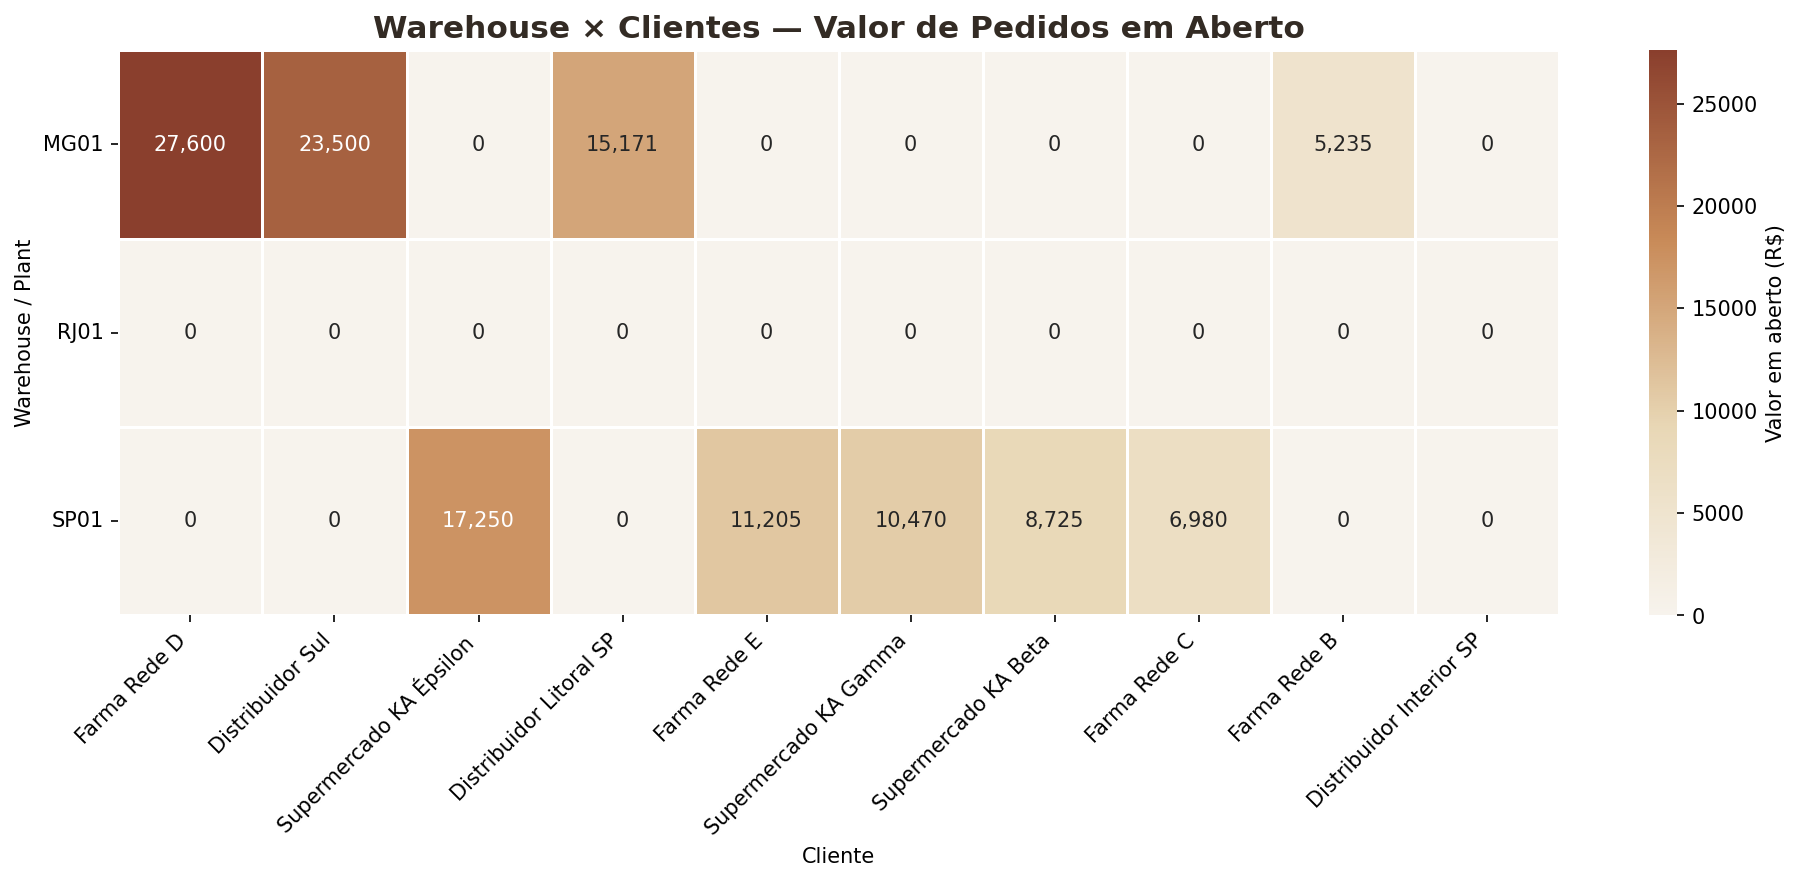

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# Paleta Mon Minou para intensidade
mon_minou_heatmap = LinearSegmentedColormap.from_list(
    "MonMinouRisk",
    [
        "#F7F3ED",
        "#E8D7B5",
        "#C88A58",
        "#8A3F2D"
    ]
)

# Figura
fig_heatmap, ax = plt.subplots(
    figsize=(13, 6)
)
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt=",.0f",
    cmap=mon_minou_heatmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Valor em aberto (R$)"
    },
    ax=ax
)

# Título

ax.set_title(
    "Warehouse × Clientes — Valor de Pedidos em Aberto",
    fontsize=15,
    fontweight="bold",
    color=COLORS["Texto"]
)


ax.set_xlabel("Cliente")
ax.set_ylabel("Warehouse / Plant")


plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)


plt.tight_layout()

# Converter para Base64

heatmap_img = figura_para_base64(
    fig_heatmap
)

# Visualizar

display(HTML(
    f"""
    <img
        src="data:image/png;base64,{heatmap_img}"
        style="
            width:100%;
            max-width:1100px;
        "
    >
    """
))

In [ ]:
# STATUS DE CAPACIDADE POR WAREHOUSE
warehouse_status = (
    df_warehouse[
        [
            "Plant",
            "Projected Utilization %",
            "Capacity Status"
        ]
    ]
    .drop_duplicates("Plant")
    .sort_values(
        "Projected Utilization %",
        ascending=False
    )
)

display(warehouse_status)

,Plant,Projected Utilization %,Capacity Status
1,RJ01,1.253750,Critical
2,SP01,1.177149,Critical
0,MG01,1.125000,Critical


In [ ]:
# TOP EXPOSIÇÕES WAREHOUSE × CUSTOMER

top_exposicoes = (
    heatmap_data_top
    .merge(
        warehouse_status,
        on="Plant",
        how="left"
    )
    .sort_values(
        "Open_Value",
        ascending=False
    )
)


display(
    top_exposicoes.head(10)
)

,Plant,Customer,Open_Value,Open_Qty,Projected Utilization %,Capacity Status
3,MG01,Farma Rede D,27600.0,400,1.125000,Critical
1,MG01,Distribuidor Sul,23500.0,500,1.125000,Critical
9,SP01,Supermercado KA Épsilon,17250.0,250,1.177149,Critical
0,MG01,Distribuidor Litoral SP,15171.0,950,1.125000,Critical
6,SP01,Farma Rede E,11205.0,900,1.177149,Critical
8,SP01,Supermercado KA Gamma,10470.0,300,1.177149,Critical
7,SP01,Supermercado KA Beta,8725.0,250,1.177149,Critical
5,SP01,Farma Rede C,6980.0,200,1.177149,Critical
2,MG01,Farma Rede B,5235.0,150,1.125000,Critical
4,RJ01,Distribuidor Interior SP,0.0,0,1.253750,Critical


In [ ]:
def gerar_alerta_heatmap(row):

    cliente = row["Customer"]
    plant = row["Plant"]

    valor = row["Open_Value"]
    utilizacao = row["Projected Utilization %"]
    status = row["Capacity Status"]

    if status == "Critical":

        return (
            f"O <b>{plant}</b> apresenta concentração de "
            f"<b>R$ {valor:,.0f}</b> em pedidos em aberto "
            f"para <b>{cliente}</b>, enquanto a utilização "
            f"projetada do warehouse está em "
            f"<b>{utilizacao:.1%}</b>. "
            f"O cruzamento indica <b>risco crítico de capacidade</b>."
        )

    elif status == "Attention":

        return (
            f"O <b>{plant}</b> concentra "
            f"<b>R$ {valor:,.0f}</b> em pedidos em aberto "
            f"para <b>{cliente}</b>, com utilização projetada "
            f"de <b>{utilizacao:.1%}</b>. "
            f"Recomenda-se monitoramento."
        )

    else:

        return (
            f"O <b>{plant}</b> concentra "
            f"<b>R$ {valor:,.0f}</b> em pedidos em aberto "
            f"para <b>{cliente}</b>, sem indicação atual "
            f"de restrição crítica de capacidade."
        )

In [ ]:
# TOP 3 EXPOSIÇÕES DE WAREHOUSE

top_exposicoes_criticas = (
    top_exposicoes[
        top_exposicoes["Capacity Status"].isin(
            ["Critical", "Attention"]
        )
    ]
    .sort_values(
        [
            "Projected Utilization %",
            "Open_Value"
        ],
        ascending=[False, False]
    )
    .head(3)
)

alertas_heatmap = []

for _, row in top_exposicoes_criticas.iterrows():

    alertas_heatmap.append(
        gerar_alerta_heatmap(row)
    )

for i, alerta in enumerate(
    alertas_heatmap,
    start=1
):

    print(
        f"ALERTA {i}:"
    )

    print(
        alerta
        .replace("<b>", "")
        .replace("</b>", "")
    )

    print()

ALERTA 1:
O RJ01 apresenta concentração de R$ 0 em pedidos em aberto para Distribuidor Interior SP, enquanto a utilização projetada do warehouse está em 125.4%. O cruzamento indica risco crítico de capacidade.

ALERTA 2:
O SP01 apresenta concentração de R$ 17,250 em pedidos em aberto para Supermercado KA Épsilon, enquanto a utilização projetada do warehouse está em 117.7%. O cruzamento indica risco crítico de capacidade.

ALERTA 3:
O SP01 apresenta concentração de R$ 11,205 em pedidos em aberto para Farma Rede E, enquanto a utilização projetada do warehouse está em 117.7%. O cruzamento indica risco crítico de capacidade.



In [ ]:
html_heatmap = f"""
<div style="
    margin-top:25px;
    padding-top:20px;
    border-top:1px solid #E6DED2;
">

<h4 style="
    margin:0 0 8px 0;
    color:{COLORS["Texto"]};
">

Concentração do Order Book por Warehouse × Cliente

</h4>

<p style="
    margin:0 0 15px 0;
    color:#777;
    font-size:13px;
">

Intensidade representa o valor financeiro dos pedidos
em aberto. Cruzamentos em warehouses com alta utilização
projetada representam maior exposição operacional.

</p>

<img
    src="data:image/png;base64,{heatmap_img}"
    style="
        width:100%;
        max-width:1100px;
        display:block;
        margin:auto;
    "
>

</div>
"""

In [ ]:
#DEMAND & WAREHOUSE RISK

if len(alertas_supply) == 0:

    html_supply_risk = f"""
    <div style="
        background:#F4F1EA;
        border-left:5px solid {COLORS["Confirmado"]};
        padding:20px;
        margin-bottom:30px;
    ">

        <h3 style="
            margin:0 0 10px 0;
            color:{COLORS["Texto"]};
        ">
            Demand & Warehouse Risk
        </h3>

        <p style="
            margin:0;
            color:{COLORS["Texto"]};
        ">
            Nenhum risco crítico ou de atenção identificado
            no cruzamento entre Demand Sensing e capacidade
            projetada do warehouse.
        </p>

    </div>
    """

else:

    # Monta os alertas em HTML
    lista_alertas = ""

    for alerta in alertas_supply:

        lista_alertas += f"""
        <li style="
            margin-bottom:10px;
            line-height:1.6;
        ">
            {alerta}
        </li>
        """

    html_supply_risk = f"""
    <div style="
        background:#FBF8F2;
        border-left:5px solid {COLORS["Negativo"]};
        padding:20px 25px;
        margin-bottom:30px;
    ">

        <h3 style="
            margin:0 0 8px 0;
            color:{COLORS["Texto"]};
        ">
            Demand & Warehouse Risk
        </h3>

        <p style="
            margin:0 0 15px 0;
            color:#777;
            font-size:13px;
        ">
            Cruzamento entre aceleração do Demand Sensing,
            capacidade projetada do warehouse e impacto
            observado no Order Book.
        </p>

        <ul style="
            margin:0;
            padding-left:22px;
            color:{COLORS["Texto"]};
        ">

            {lista_alertas}

        </ul>

    </div>
    """

In [ ]:
# HTML top supply risks

if len(top_supply_risks) == 0:

    html_top_riscos = f"""
    <h3 style="
        margin-top:0;
        color:{COLORS["Texto"]};
    ">
        Top Riscos
    </h3>

    <p style="
        color:#777;
        font-size:13px;
        line-height:1.5;
    ">
        Nenhum risco crítico ou de atenção
        identificado no cenário atual.
    </p>
    """

else:

    lista_top_riscos = ""

    for _, row in top_supply_risks.head(5).iterrows():

        sku = row["SKU Description"]
        plant = row["Plant"]
        risk = row["Supply Risk"]

        forecast = row["Forecast_Variation_%"]
        utilization = row["Projected Utilization %"]
        rejected = row["Rejected_Value"]

        # Define a prioridade visual

        if risk == "Critical":

            cor_risco = COLORS["Negativo"]

        else:

            cor_risco = "#B59A45"


        lista_top_riscos += f"""
        <li style="
            margin-bottom:12px;
            line-height:1.5;
        ">

            <span style="
                color:{cor_risco};
                font-weight:bold;
            ">
                {risk}
            </span>

            — <b>{sku}</b>
            ({plant})

            <br>

            <span style="
                color:#777;
                font-size:12px;
            ">

            Forecast:
            {forecast:.1%}

            &nbsp; | &nbsp;

            Utilização:
            {utilization:.1%}

            &nbsp; | &nbsp;

            Rejeição:
            R$ {rejected:,.0f}

            </span>

        </li>
        """


    html_top_riscos = f"""
    <h3 style="
        margin-top:0;
        color:{COLORS["Texto"]};
    ">
        Top Riscos
    </h3>

    <p style="
        margin-top:0;
        color:#777;
        font-size:13px;
        line-height:1.5;
    ">

        Principais combinações de risco identificadas
        no cruzamento entre demanda, pedidos e capacidade.

    </p>

    <ul style="
        margin:0;
        padding-left:20px;
        color:{COLORS["Texto"]};
    ">

        {lista_top_riscos}

    </ul>
    """

In [ ]:
# Identifica os principais pontos de atenção

pontos_previa = []

# Supply Risk
if "Supply Risk" in df_supply_risk.columns:

    critical_count = (
        df_supply_risk["Supply Risk"]
        .eq("Critical")
        .sum()
    )

    attention_count = (
        df_supply_risk["Supply Risk"]
        .eq("Attention")
        .sum()
    )

    if critical_count > 0:

        pontos_previa.append(
            f"{critical_count} SKU(s) em risco crítico de supply."
        )

    if attention_count > 0:

        pontos_previa.append(
            f"{attention_count} SKU(s) em atenção."
        )


# Capacidade
if "Capacity Status" in df_warehouse.columns:

    plants_critical = (
        df_warehouse["Capacity Status"]
        .eq("Critical")
        .sum()
    )

    plants_attention = (
        df_warehouse["Capacity Status"]
        .eq("Attention")
        .sum()
    )

    if plants_critical > 0:

        pontos_previa.append(
            f"{plants_critical} warehouse(s) em nível crítico de capacidade."
        )

    if plants_attention > 0:

        pontos_previa.append(
            f"{plants_attention} warehouse(s) em atenção."
        )


# 3. CSL
if "Rejection Reason" in df.columns:

    csl_value = (
        df.loc[
            df["Rejection Reason"] == "Corte CSL",
            "Net Value (R$)"
        ]
        .sum()
    )

    if total_entrada > 0:

        csl_pct = (
            csl_value / total_entrada
        )

        if csl_pct > 0.10:

            pontos_previa.append(
                f"Corte CSL representa {csl_pct:.1%} "
                "da entrada de pedidos."
            )

        elif csl_pct > 0.05:

            pontos_previa.append(
                f"Corte CSL representa {csl_pct:.1%} "
                "da entrada de pedidos."
            )


# 4. Conversão do Order Book
if conversao < 0.90:

    pontos_previa.append(
        f"Conversão do Order Book em {conversao:.1%}, "
        "abaixo do nível de 90%."
    )

elif conversao < 0.95:

    pontos_previa.append(
        f"Conversão do Order Book em {conversao:.1%}, "
        "abaixo do nível de 95%."
    )


# ------------------------------------------
# Se não houver criticidades
# ------------------------------------------

if len(pontos_previa) == 0:

    pontos_previa.append(
        "Nenhum novo ponto crítico identificado "
        "para o próximo disparo."
    )


# ------------------------------------------
# Montagem HTML
# ------------------------------------------

lista_previa = ""

for ponto in pontos_previa:

    lista_previa += f"""
    <li style="
        margin-bottom:10px;
        line-height:1.5;
    ">
        {ponto}
    </li>
    """


html_proxima_previa = f"""

<h3 style="
    margin-top:0;
    color:{COLORS["Texto"]};
">

Prévia do Próximo Disparo

</h3>

<p style="
    margin-top:0;
    color:#777;
    font-size:13px;
    line-height:1.5;
">

Pontos que devem ser monitorados no próximo ciclo
do Sales Order Funnel.

</p>

<ul style="
    margin:0;
    padding-left:20px;
    color:{COLORS["Texto"]};
">

{lista_previa}

</ul>

"""

In [ ]:
# ==========================================
# HTML COMPLETO — RELATÓRIO FUNIL DE PEDIDOS
# ==========================================

# ==========================================
# 1. GARANTIR QUE OS BLOCOS NECESSÁRIOS EXISTEM
# ==========================================

# Caso o bloco de Supply Risk ainda não tenha sido
# criado, utilizamos uma mensagem neutra.

if "html_supply_risk" not in globals():

    html_supply_risk = f"""
    <h3 style="
        margin-top:0;
        color:{COLORS["Texto"]};
    ">
        Demand & Warehouse Risk
    </h3>

    <p style="
        color:#777;
        font-size:13px;
    ">
        Informações de risco de demanda e capacidade
        não disponíveis nesta execução.
    </p>
    """


# Caso o heatmap ainda não exista

if "heatmap_img" in globals():

    html_heatmap_bloco = f"""

    <h3 style="
        margin-top:0;
        color:{COLORS["Texto"]};
    ">
        Warehouse × Clientes
    </h3>

    <p style="
        margin:0 0 15px 0;
        color:#777;
        font-size:13px;
    ">

    Concentração do valor de pedidos em aberto
    por warehouse e cliente.

    </p>

    <img
        src="data:image/png;base64,{heatmap_img}"
        style="
            width:100%;
            display:block;
            margin:auto;
        "
    >

    """

else:

    html_heatmap_bloco = f"""

    <h3 style="
        margin-top:0;
        color:{COLORS["Texto"]};
    ">
        Warehouse × Clientes
    </h3>

    <p style="
        color:#777;
        font-size:13px;
    ">
        Heatmap não disponível nesta execução.
    </p>

    """


# ==========================================
# 2. TABLEAU
# ==========================================

if "html_tableau" not in globals():

    if "TABLEAU_URL" in globals():

        html_tableau = f"""
        <div style="
            margin-top:30px;
            margin-bottom:30px;
            padding:20px;
            background:#F7F3ED;
            border:1px solid #E6DED2;
            text-align:center;
        ">

        <h3 style="
            margin:0 0 8px 0;
            color:{COLORS["Texto"]};
        ">
            Análises Complementares
        </h3>

        <p style="
            margin:0 0 15px 0;
            color:#777;
            font-size:13px;
        ">

        Explore o Order Book, clientes, SKUs,
        Demand Sensing e capacidade logística.

        </p>

        <a
            href="{TABLEAU_URL}"
            target="_blank"
            style="
                display:inline-block;
                background:{COLORS["Confirmado"]};
                color:white;
                padding:12px 24px;
                text-decoration:none;
                font-weight:bold;
                font-size:13px;
                border-radius:4px;
            "
        >

        Abrir Dashboard no Tableau Public

        </a>

        </div>
        """

    else:

        html_tableau = ""


# ==========================================
# 3. HTML PRINCIPAL
# ==========================================

html_relatorio = f"""
<!DOCTYPE html>

<html>

<head>

<meta charset="UTF-8">

<title>Funil de Pedidos</title>

</head>


<body style="
    margin:0;
    padding:0;
    background-color:#F7F3ED;
    font-family:Arial, Helvetica, sans-serif;
    color:{COLORS["Texto"]};
">


<div style="
    max-width:1200px;
    margin:30px auto;
    background:white;
    padding:35px;
    box-sizing:border-box;
">


<!-- ===================================== -->
<!-- CABEÇALHO -->
<!-- ===================================== -->

<div style="
    border-bottom:3px solid {COLORS["Confirmado"]};
    padding-bottom:20px;
    margin-bottom:25px;
">

<h1 style="
    margin:0;
    color:{COLORS["Texto"]};
    font-size:26px;
">

Funil de Pedidos

</h1>

<p style="
    margin:8px 0 0 0;
    color:#777;
    font-size:13px;
">

Sales Order Funnel | Mon Minou Chocolaterie

</p>

</div>


<!-- ===================================== -->
<!-- RESUMO + ALERTAS -->
<!-- ===================================== -->

<div style="
    display:flex;
    gap:20px;
    width:100%;
    margin-bottom:30px;
    align-items:stretch;
">


<!-- RESUMO EXECUTIVO -->

<div style="
    flex:1;
    min-width:0;
    background:#FBF8F2;
    border:1px solid #E6DED2;
    padding:20px;
    box-sizing:border-box;
">

{resumo}

</div>


<!-- ALERTAS PRIORITÁRIOS -->

<div style="
    flex:1;
    min-width:0;
    background:#FBF8F2;
    border:1px solid #E6DED2;
    padding:20px;
    box-sizing:border-box;
">

{html_alertas}

</div>


</div>


<!-- ===================================== -->
<!-- WATERFALL -->
<!-- ===================================== -->

<div style="
    margin-bottom:35px;
">

<h3 style="
    color:{COLORS["Texto"]};
    margin-top:0;
">

Dinâmica do Funil

</h3>

<img
    src="data:image/png;base64,{waterfall_img}"
    style="
        width:100%;
        max-width:1000px;
        display:block;
        margin:auto;
    "
>

</div>


<!-- ===================================== -->
<!-- DEMAND & WAREHOUSE RISK + HEATMAP -->
<!-- ===================================== -->

<div style="
    display:flex;
    gap:20px;
    width:100%;
    margin-bottom:35px;
    align-items:stretch;
">


<!-- DEMAND & WAREHOUSE RISK -->

<div style="
    flex:1;
    min-width:0;
    background:#FBF8F2;
    border:1px solid #E6DED2;
    padding:20px;
    box-sizing:border-box;
">

{html_supply_risk}

</div>


<!-- HEATMAP -->

<div style="
    flex:1;
    min-width:0;
    background:#FBF8F2;
    border:1px solid #E6DED2;
    padding:20px;
    box-sizing:border-box;
">

{html_heatmap_bloco}

</div>


</div>


<!-- ===================================== -->
<!-- TOP RISCOS + PRÓXIMO DISPARO -->
<!-- ===================================== -->

<div style="
    display:flex;
    gap:25px;
    width:100%;
    margin-bottom:35px;
    padding:20px;
    background:#FBF8F2;
    border:1px solid #E6DED2;
    box-sizing:border-box;
    align-items:flex-start;
">


<!-- TOP RISCOS -->

<div style="
    flex:1;
    min-width:0;
    border-right:1px solid #E6DED2;
    padding-right:25px;
    box-sizing:border-box;
">

{html_top_riscos}

</div>


<!-- PRÓXIMO DISPARO -->

<div style="
    flex:1;
    min-width:0;
    box-sizing:border-box;
">

{html_proxima_previa}

</div>


</div>


<!-- ===================================== -->
<!-- PRINCIPAIS PONTOS DE REJEIÇÃO -->
<!-- ===================================== -->

<h3 style="
    color:{COLORS["Texto"]};
    margin-top:0;
    margin-bottom:20px;
">

Principais Pontos de Rejeição

</h3>


<!-- ===================================== -->
<!-- TRÊS GRÁFICOS LADO A LADO -->
<!-- ===================================== -->

<div style="
    display:flex;
    gap:20px;
    width:100%;
    align-items:flex-start;
">


<!-- TOP CANAIS CSL -->

<div style="
    flex:1;
    min-width:0;
    box-sizing:border-box;
">

<img
    src="data:image/png;base64,{csl_img}"
    style="
        width:100%;
        display:block;
    "
>

</div>


<!-- TOP CLIENTES -->

<div style="
    flex:1;
    min-width:0;
    box-sizing:border-box;
">

<img
    src="data:image/png;base64,{clientes_img}"
    style="
        width:100%;
        display:block;
    "
>

</div>


<!-- TOP SKUs -->

<div style="
    flex:1;
    min-width:0;
    box-sizing:border-box;
">

<img
    src="data:image/png;base64,{skus_img}"
    style="
        width:100%;
        display:block;
    "
>

</div>


</div>


<!-- ===================================== -->
<!-- TABLEAU PUBLIC -->
<!-- ===================================== -->

{html_tableau}


<!-- ===================================== -->
<!-- RODAPÉ -->
<!-- ===================================== -->

<div style="
    border-top:1px solid #E6DED2;
    padding-top:15px;
    margin-top:35px;
    color:#888;
    font-size:11px;
">

Relatório automático — Sales Order Funnel

</div>


</div>

</body>

</html>
"""


# ==========================================
# 4. VALIDAÇÃO
# ==========================================

print("HTML criado com sucesso.")

print(
    f"Tamanho do relatório: "
    f"{len(html_relatorio):,} caracteres"
)

print(
    "html_relatorio existe:",
    "html_relatorio" in globals()
)


# ==========================================
# 5. VISUALIZAR
# ==========================================

display(
    HTML(html_relatorio)
)

NameError: name 'csl_img' is not defined

In [ ]:
arquivo_html = "Funil_de_Pedidos.html"

with open(
    arquivo_html,
    "w",
    encoding="utf-8"
) as f:
    f.write(html_relatorio)

print(f"Relatório salvo em: {arquivo_html}")

NameError: name 'html_relatorio' is not defined

In [ ]:
import os

print(os.path.abspath(arquivo_html))

c:\Users\sylfe\OneDrive\Documentos\DADOS\orders_funnel_soe\Funil_de_Pedidos.html


In [ ]:
import smtplib
from email.message import EmailMessage
from pathlib import Path


def enviar_relatorio_html(
    destinatario,
    arquivo_html,
    assunto="Funil de Pedidos"
):

    remetente = "sylferreira@outlook.com"

    mensagem = EmailMessage()

    mensagem["From"] = remetente
    mensagem["To"] = destinatario
    mensagem["Subject"] = assunto

    mensagem.set_content(
        """
Olá,

Segue o relatório diário do Sales Order Funnel.

O relatório completo está no arquivo HTML anexado.

Atenciosamente,
Sales Order Funnel
"""
    )

    # Anexa o HTML
    caminho = Path(arquivo_html)

    with open(caminho, "rb") as arquivo:

        mensagem.add_attachment(
            arquivo.read(),
            maintype="text",
            subtype="html",
            filename=caminho.name
        )

    # Outlook SMTP
    with smtplib.SMTP(
        "smtp-mail.outlook.com",
        587
    ) as servidor:

        servidor.starttls()

        servidor.login(
            remetente,
            senha
        )

        servidor.send_message(mensagem)

    print(
        f"Relatório enviado para {destinatario}"
    )

In [ ]:
# ==========================================
# GERAR HTML + E-MAIL .EML
# ==========================================

from email.message import EmailMessage
import subprocess


def gerar_email_funil(
    html,
    destinatario="sylferreira@outlook.com",
    assunto="Funil de Pedidos",
    pasta_saida="."
):
    
    # --------------------------------------
    # Pasta de saída
    # --------------------------------------
    
    pasta = Path(pasta_saida)
    pasta.mkdir(parents=True, exist_ok=True)
    
    
    # --------------------------------------
    # Arquivos
    # --------------------------------------
    
    arquivo_html = pasta / "Funil_de_Pedidos.html"
    arquivo_eml = pasta / "Funil_de_Pedidos.eml"
    
    
    # --------------------------------------
    # Salvar HTML
    # --------------------------------------
    
    arquivo_html.write_text(
        html,
        encoding="utf-8"
    )
    
    
    # --------------------------------------
    # Criar mensagem
    # --------------------------------------
    
    mensagem = EmailMessage()
    
    mensagem["To"] = destinatario
    mensagem["Subject"] = assunto
    
    mensagem.set_content(
        "Segue o relatório Funil de Pedidos."
    )
    
    
    # --------------------------------------
    # Adicionar HTML como corpo
    # --------------------------------------
    
    mensagem.add_alternative(
        html,
        subtype="html"
    )
    
    
    # --------------------------------------
    # Salvar .EML
    # --------------------------------------
    
    with open(
        arquivo_eml,
        "wb"
    ) as arquivo:
        
        arquivo.write(
            bytes(mensagem)
        )
    
    
    # --------------------------------------
    # Abrir no Windows / Outlook
    # --------------------------------------
    
    subprocess.Popen(
        ["explorer.exe", str(arquivo_eml)]
    )
    
    
    print("======================================")
    print("E-mail preparado com sucesso!")
    print("======================================")
    print(f"HTML: {arquivo_html.resolve()}")
    print(f"EML : {arquivo_eml.resolve()}")
    print()
    print("O arquivo .EML foi aberto.")
    print("Revise o e-mail e clique em ENVIAR no Outlook.")
    

In [ ]:
gerar_email_funil(
    html=html_relatorio,
    destinatario="sylferreira@outlook.com",
    assunto="Funil de Pedidos"
)

NameError: name 'html_relatorio' is not defined

Linhas da FACT_ORDER_DAILY: 30
Linhas da FACT_SALES_ORDER_ANALYTICS: 30
Colunas: 38


,Snapshot Date,Sales Order,Item,Customer ID,Customer,Channel,Material ID,SKU Description,Category,Plant,...,Demand Sensing Forecast Qty_Warehouse,Projected Occupancy,Projected Utilization %,Capacity Status,Rejected Value (R$),Forecast Variation %,Demand Risk,Capacity Risk,Supply Risk Score,Supply Risk
0,2026-08-18,45000001,10,C0001,Mon Minou Shopping Morumbi,Loja Própria,MM30-ML-01,Barra Chocolate ao Leite 30g,Barras,SP01,...,9982.5,13494.75,1.092432,Critical,0.0,-0.050000,Normal,Critical,2,Attention
1,2026-08-18,45000002,10,C0002,Mon Minou Shopping Eldorado,Loja Própria,MM30-GC-01,Barra Gold Caramel 30g,Barras,SP01,...,9982.5,13494.75,1.092432,Critical,11205.0,0.100000,Critical,Critical,4,Critical
2,2026-08-18,45000003,10,C0003,Mon Minou Shopping Iguatemi,Loja Própria,MM75-RB-01,Barra Chocolate Raspberry 75g,Barras,SP01,...,9982.5,13494.75,1.092432,Critical,10470.0,0.082524,Attention,Critical,3,Critical
3,2026-08-18,45000004,10,C0101,Supermercado KA Alpha,Supermercado KA,MM75-60-01,Barra Chocolate 60% 75g,Barras,SP01,...,9982.5,13494.75,1.092432,Critical,0.0,-0.050000,Normal,Critical,2,Attention
4,2026-08-18,45000005,10,C0102,Supermercado KA Beta,Supermercado KA,MM75-LS-01,Barra Chocolate Branco Limão Siciliano 75g,Barras,SP01,...,9982.5,13494.75,1.092432,Critical,12215.0,0.100000,Critical,Critical,4,Critical
5,2026-08-18,45000006,10,C0103,Supermercado KA Gamma,Supermercado KA,MM75-RB-01,Barra Chocolate Raspberry 75g,Barras,SP01,...,9982.5,13494.75,1.092432,Critical,10470.0,0.082524,Attention,Critical,3,Critical
6,2026-08-18,45000007,10,C0104,Supermercado KA Delta,Supermercado KA,MM09-BN-01,Caixa 9 Bonbons Sortidos,Bonbons,SP01,...,9982.5,13494.75,1.092432,Critical,17250.0,0.021739,Normal,Critical,2,Attention
7,2026-08-18,45000008,10,C0105,Supermercado KA Épsilon,Supermercado KA,MM09-BN-01,Caixa 9 Bonbons Sortidos,Bonbons,SP01,...,9982.5,13494.75,1.092432,Critical,17250.0,0.021739,Normal,Critical,2,Attention
8,2026-08-18,45000009,10,C0201,Distribuidor SP Capital,Distribuidor,MM30-ML-01,Barra Chocolate ao Leite 30g,Barras,RJ01,...,3800.0,5140.00,1.092250,Critical,0.0,-0.050000,Normal,Critical,2,Attention
9,2026-08-18,45000010,10,C0202,Distribuidor Litoral SP,Distribuidor,MM30-GC-01,Barra Gold Caramel 30g,Barras,MG01,...,6400.0,8720.00,1.090000,Critical,9936.0,0.100000,Critical,Critical,4,Critical
